In [1]:
from pathlib import Path
import os

root = Path.cwd()

while not (root / ".git").exists():
    root = root.parent

os.chdir(root)

print("Project root:", root)

Project root: d:\Projects\btc-research-lab


In [2]:
from statsmodels.tsa.stattools import acf

In [3]:
import pandas as pd
import numpy as np

df = pd.read_parquet("data/processed/BTCUSDT_5m_regularized.parquet")

df["open_time"] = pd.to_datetime(df["open_time"])
df = df.sort_values("open_time").reset_index(drop=True)
df.head()

,open_time,open,high,low,close,volume
0,2019-01-01 00:00:00,3701.23,3703.72,3695.00,3696.32,85.572181
1,2019-01-01 00:05:00,3696.30,3697.24,3689.88,3692.34,62.296581
2,2019-01-01 00:10:00,3692.34,3698.93,3692.34,3697.31,43.105333
3,2019-01-01 00:15:00,3697.91,3698.75,3693.00,3693.00,48.551084
4,2019-01-01 00:20:00,3693.44,3695.98,3690.92,3692.18,47.706443


In [4]:
df["log_close"] = np.log(df["close"])
df["returns"] = df["log_close"].diff()
df = df.dropna().reset_index(drop=True)

In [5]:
from scipy.stats import skew, kurtosis

df["returns"].describe()
skew(df["returns"]), kurtosis(df["returns"])

(np.float64(-0.1914766446025681), np.float64(166.65566386464698))

In [6]:
df["rolling_vol"] = df["returns"].rolling(96).std()

In [7]:
df["rolling_vol"].describe()

count    631200.000000
mean          0.001741
std           0.001280
min           0.000000
25%           0.000998
50%           0.001452
75%           0.002092
max           0.029338
Name: rolling_vol, dtype: float64

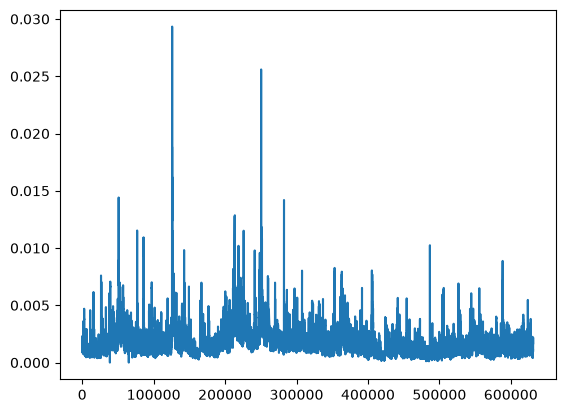

In [8]:
import matplotlib.pyplot as plt

plt.plot(df["rolling_vol"])
plt.show()

In [9]:
for col in df.columns:
    print(col)

open_time
open
high
low
close
volume
log_close
returns
rolling_vol


In [10]:
df['rolling_vol'].describe()

count    631200.000000
mean          0.001741
std           0.001280
min           0.000000
25%           0.000998
50%           0.001452
75%           0.002092
max           0.029338
Name: rolling_vol, dtype: float64

In [11]:
df['rolling_vol'].head(20)


0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
Name: rolling_vol, dtype: float64

In [12]:
window = 48

df['rv'] = (df['returns'] ** 2).rolling(window=window).sum()

df = df.dropna(subset=['rv'])

df['rv_smooth'] = df['rv'].ewm(span=10, adjust=False).mean()

In [13]:
df[['returns', 'rv', 'rv_smooth']].head(10)

,returns,rv,rv_smooth
47,0.000766,0.000041,0.000041
48,0.002713,0.000047,0.000042
49,0.000318,0.000045,0.000043
50,-0.000281,0.000044,0.000043
51,-0.002696,0.000051,0.000044
52,0.000097,0.000051,0.000046
53,0.000446,0.000047,0.000046
54,-0.000549,0.000048,0.000046
55,-0.000447,0.000048,0.000046
56,0.000422,0.000045,0.000046


In [14]:
q1 = df['rv_smooth'].quantile(1/3)
q2 = df['rv_smooth'].quantile(2/3)

df['regime'] = np.where(df['rv_smooth'] <= q1, 0,
                  np.where(df['rv_smooth'] <= q2, 1, 2))

In [15]:
df['regime'].value_counts(normalize=True)

regime
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64

In [16]:
import pandas as pd

transition = pd.crosstab(df['regime'], df['regime'].shift(-1), normalize=0)
transition

regime,0.0,1.0,2.0
regime,,,
0,0.990257,0.009681,0.000062
1,0.009738,0.980510,0.009752
2,0.000000,0.009814,0.990186


In [17]:
transition.values.diagonal()

array([0.99025739, 0.98050994, 0.99018611])

In [18]:
df_shuffled = df.copy()
df_shuffled['regime'] = np.random.permutation(df_shuffled['regime'].values)

transition_shuffled = pd.crosstab(
    df_shuffled['regime'],
    df_shuffled['regime'].shift(-1),
    normalize=0
)

transition_shuffled

regime,0.0,1.0,2.0
regime,,,
0,0.333230,0.333435,0.333335
1,0.331844,0.333845,0.334311
2,0.334927,0.332717,0.332356


In [19]:
regime_stats = df.groupby('regime')['returns'].agg([
    'mean',
    'std',
    'count'
])

print(regime_stats)

            mean       std   count
regime                            
0       0.000004  0.000916  210416
1       0.000003  0.001567  210416
2       0.000008  0.003269  210416


In [20]:
df.groupby('regime')['returns'].quantile(
    [0.01,0.05,0.25,0.5,0.75,0.95,0.99]
)

regime      
0       0.01   -0.002472
        0.05   -0.001350
        0.25   -0.000445
        0.50    0.000000
        0.75    0.000452
        0.95    0.001367
        0.99    0.002504
1       0.01   -0.004192
        0.05   -0.002282
        0.25   -0.000805
        0.50    0.000000
        0.75    0.000825
        0.95    0.002286
        0.99    0.004136
2       0.01   -0.008648
        0.05   -0.004288
        0.25   -0.001363
        0.50    0.000002
        0.75    0.001393
        0.95    0.004314
        0.99    0.008556
Name: returns, dtype: float64

In [21]:
future_return = df['returns'].shift(-1)

df.groupby('regime').apply(
    lambda x: future_return.loc[x.index].mean()
)

regime
0    0.000001
1    0.000004
2    0.000010
dtype: float64

In [22]:
df['future_return'] = df['returns'].shift(-1)

df.groupby('regime')['future_return'].agg([
    'mean',
    'std',
    'count'
])

,mean,std,count
regime,,,
0,0.000001,0.001036,210416
1,0.000004,0.001647,210415
2,0.000010,0.003192,210416


In [23]:
from statsmodels.tsa.stattools import acf

acf_returns = acf(
    df['returns'].dropna(),
    nlags=20,
    fft=True
)

for lag, value in enumerate(acf_returns):
    print(f"Lag {lag}: {value:.6f}")

Lag 0: 1.000000
Lag 1: -0.032476
Lag 2: -0.016649
Lag 3: 0.009659
Lag 4: -0.006744
Lag 5: -0.016473
Lag 6: -0.012432
Lag 7: 0.007295
Lag 8: 0.000647
Lag 9: -0.000589
Lag 10: 0.001270
Lag 11: 0.005444
Lag 12: -0.006210
Lag 13: -0.003798
Lag 14: -0.000388
Lag 15: -0.005417
Lag 16: -0.000429
Lag 17: -0.001426
Lag 18: -0.001433
Lag 19: 0.000927
Lag 20: 0.000026


In [24]:
acf_abs = acf(
    df['returns'].abs().dropna(),
    nlags=20,
    fft=True
)

for lag, value in enumerate(acf_abs):
    print(f"Lag {lag}: {value:.6f}")

Lag 0: 1.000000
Lag 1: 0.388789
Lag 2: 0.350860
Lag 3: 0.325320
Lag 4: 0.305559
Lag 5: 0.297624
Lag 6: 0.292150
Lag 7: 0.280367
Lag 8: 0.273273
Lag 9: 0.271331
Lag 10: 0.264135
Lag 11: 0.257413
Lag 12: 0.263455
Lag 13: 0.252539
Lag 14: 0.247858
Lag 15: 0.248300
Lag 16: 0.238463
Lag 17: 0.237838
Lag 18: 0.241386
Lag 19: 0.232426
Lag 20: 0.228345


In [25]:
acf_sq = acf(
    (df['returns']**2).dropna(),
    nlags=20,
    fft=True
)

for lag, value in enumerate(acf_sq):
    print(f"Lag {lag}: {value:.6f}")

Lag 0: 1.000000
Lag 1: 0.253087
Lag 2: 0.262433
Lag 3: 0.166179
Lag 4: 0.140399
Lag 5: 0.143193
Lag 6: 0.090826
Lag 7: 0.092497
Lag 8: 0.098131
Lag 9: 0.117605
Lag 10: 0.077709
Lag 11: 0.065099
Lag 12: 0.057070
Lag 13: 0.078624
Lag 14: 0.057161
Lag 15: 0.057428
Lag 16: 0.040345
Lag 17: 0.053616
Lag 18: 0.046030
Lag 19: 0.043521
Lag 20: 0.037934


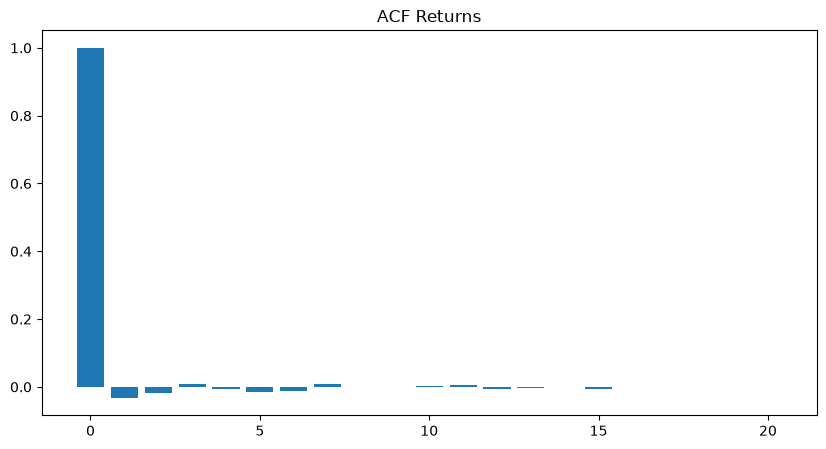

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(range(len(acf_returns)), acf_returns)
plt.title("ACF Returns")
plt.show()

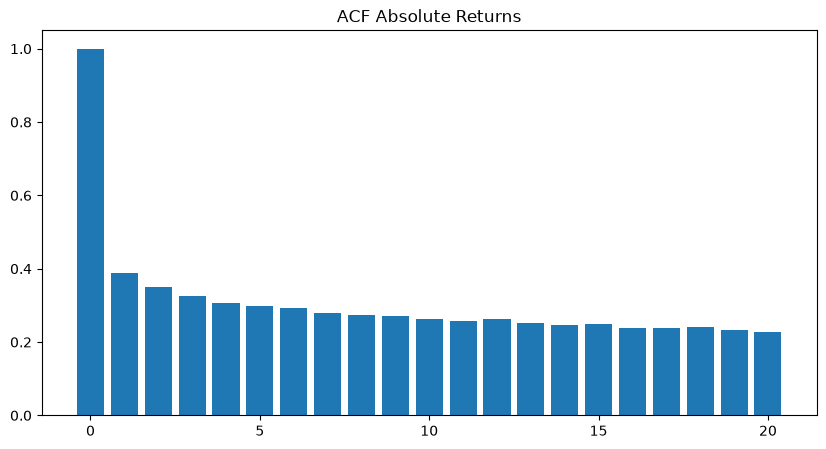

In [27]:
plt.figure(figsize=(10,5))
plt.bar(range(len(acf_abs)), acf_abs)
plt.title("ACF Absolute Returns")
plt.show()

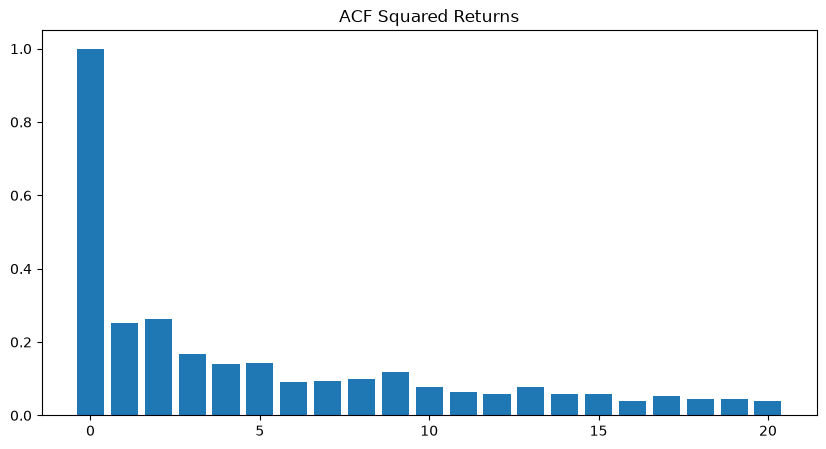

In [28]:
plt.figure(figsize=(10,5))
plt.bar(range(len(acf_sq)), acf_sq)
plt.title("ACF Squared Returns")
plt.show()

In [29]:
import numpy as np
import matplotlib.pyplot as plt

df['returns'] = df['returns'].astype(float)

In [30]:
df_low = df.loc[df['regime'] == 0, 'returns'].dropna()
df_mid = df.loc[df['regime'] == 1, 'returns'].dropna()
df_high = df.loc[df['regime'] == 2, 'returns'].dropna()

print("Low Vol :", len(df_low))
print("Mid Vol :", len(df_mid))
print("High Vol:", len(df_high))

Low Vol : 210416
Mid Vol : 210416
High Vol: 210416


In [31]:
def autocorr(x, max_lag=20):
    x = np.asarray(x)
    x = x - x.mean()

    acf = [1.0]

    var = np.dot(x, x)

    for lag in range(1, max_lag + 1):
        cov = np.dot(x[:-lag], x[lag:])
        acf.append(cov / var)

    return np.array(acf)

In [32]:
max_lag = 20

acf_low = autocorr(df_low, max_lag)
acf_mid = autocorr(df_mid, max_lag)
acf_high = autocorr(df_high, max_lag)

for lag in range(max_lag + 1):
    print(
        f"Lag {lag:2d} | "
        f"Low={acf_low[lag]: .5f} | "
        f"Mid={acf_mid[lag]: .5f} | "
        f"High={acf_high[lag]: .5f}"
    )

Lag  0 | Low= 1.00000 | Mid= 1.00000 | High= 1.00000
Lag  1 | Low=-0.02968 | Mid=-0.02009 | High=-0.03748
Lag  2 | Low=-0.01448 | Mid=-0.00615 | High=-0.02172
Lag  3 | Low=-0.00289 | Mid= 0.00259 | High= 0.01115
Lag  4 | Low=-0.00966 | Mid= 0.00030 | High=-0.00878
Lag  5 | Low=-0.00362 | Mid=-0.00521 | High=-0.02099
Lag  6 | Low=-0.00886 | Mid=-0.00041 | High=-0.01663
Lag  7 | Low= 0.00122 | Mid= 0.00318 | High= 0.00808
Lag  8 | Low=-0.00185 | Mid=-0.00335 | High= 0.00233
Lag  9 | Low= 0.00285 | Mid= 0.00268 | High=-0.00145
Lag 10 | Low= 0.00019 | Mid= 0.00010 | High= 0.00167
Lag 11 | Low=-0.00171 | Mid=-0.00012 | High= 0.00811
Lag 12 | Low= 0.00365 | Mid= 0.00044 | High=-0.00843
Lag 13 | Low=-0.00449 | Mid=-0.00173 | High=-0.00545
Lag 14 | Low=-0.00017 | Mid= 0.00286 | High=-0.00117
Lag 15 | Low=-0.00067 | Mid= 0.00214 | High=-0.00825
Lag 16 | Low=-0.00097 | Mid=-0.00052 | High=-0.00101
Lag 17 | Low=-0.00033 | Mid=-0.00135 | High=-0.00182
Lag 18 | Low= 0.00517 | Mid= 0.00404 | High=-0

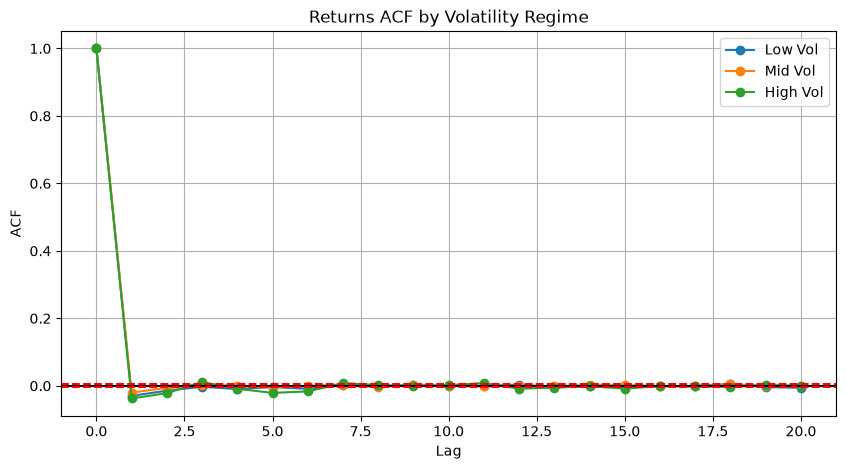

In [33]:
lags = np.arange(max_lag + 1)

plt.figure(figsize=(10,5))

plt.plot(lags, acf_low, marker='o', label='Low Vol')
plt.plot(lags, acf_mid, marker='o', label='Mid Vol')
plt.plot(lags, acf_high, marker='o', label='High Vol')

plt.axhline(0, color='black')

# approximate 95% confidence band
conf = 1.96 / np.sqrt(min(len(df_low), len(df_mid), len(df_high)))

plt.axhline(conf, color='red', linestyle='--')
plt.axhline(-conf, color='red', linestyle='--')

plt.xlabel("Lag")
plt.ylabel("ACF")
plt.title("Returns ACF by Volatility Regime")
plt.legend()
plt.grid(True)

plt.show()

In [34]:
def sign_transition(series, lag=1):
    
    x = np.sign(series.values)

    current = x[:-lag]
    future = x[lag:]

    mask = (current != 0) & (future != 0)

    current = current[mask]
    future = future[mask]

    same = np.mean(current == future)
    opposite = np.mean(current != future)

    return same, opposite

In [35]:
for lag in [1, 2, 3]:

    same, opposite = sign_transition(df_low, lag)

    print(
        f"Low Vol | Lag {lag} | "
        f"Same={same:.4f} | Opposite={opposite:.4f}"
    )

Low Vol | Lag 1 | Same=0.4829 | Opposite=0.5171
Low Vol | Lag 2 | Same=0.4865 | Opposite=0.5135
Low Vol | Lag 3 | Same=0.4919 | Opposite=0.5081


In [36]:
for lag in [1, 2, 3]:

    same, opposite = sign_transition(df_mid, lag)

    print(
        f"Mid Vol | Lag {lag} | "
        f"Same={same:.4f} | Opposite={opposite:.4f}"
    )

Mid Vol | Lag 1 | Same=0.4782 | Opposite=0.5218
Mid Vol | Lag 2 | Same=0.4856 | Opposite=0.5144
Mid Vol | Lag 3 | Same=0.4933 | Opposite=0.5067


In [37]:
for lag in [1, 2, 3]:

    same, opposite = sign_transition(df_high, lag)

    print(
        f"High Vol | Lag {lag} | "
        f"Same={same:.4f} | Opposite={opposite:.4f}"
    )

High Vol | Lag 1 | Same=0.4775 | Opposite=0.5225
High Vol | Lag 2 | Same=0.4830 | Opposite=0.5170
High Vol | Lag 3 | Same=0.4942 | Opposite=0.5058


In [39]:
df['fwd_1'] = df['returns'].shift(-1)

df['fwd_3'] = (
    df['returns'].shift(-1)
    + df['returns'].shift(-2)
    + df['returns'].shift(-3)
)

df['fwd_6'] = (
    df['returns'].shift(-1)
    + df['returns'].shift(-2)
    + df['returns'].shift(-3)
    + df['returns'].shift(-4)
    + df['returns'].shift(-5)
    + df['returns'].shift(-6)
)

In [40]:
df['next_regime'] = df['regime'].shift(-1)

df['transition'] = (
    df['regime'].astype(int).astype(str)
    + "→"
    + df['next_regime'].astype('Int64').astype(str)
)

In [41]:
transition_df = df.dropna(
    subset=['transition', 'fwd_1', 'fwd_3', 'fwd_6']
).copy()

print(len(transition_df))

631242


In [42]:
summary = (
    transition_df
    .groupby('transition')
    .agg(
        count=('returns', 'size'),
        mean_1=('fwd_1', 'mean'),
        mean_3=('fwd_3', 'mean'),
        mean_6=('fwd_6', 'mean'),
        std_1=('fwd_1', 'std')
    )
    .sort_values('count', ascending=False)
)

summary

,count,mean_1,mean_3,mean_6,std_1
transition,,,,,
0→0,208366,0.000005,0.000007,0.000015,0.000917
2→2,208351,0.000010,0.000030,0.000061,0.003206
1→1,206309,0.000006,0.000013,0.000020,0.001526
2→1,2065,0.000005,0.000050,0.000133,0.001202
1→2,2052,-0.000216,-0.000190,-0.000105,0.006608
1→0,2049,-0.000004,-0.000005,-0.000126,0.000761
0→1,2037,-0.000260,-0.000213,-0.000170,0.004028
0→2,13,-0.009629,-0.009991,-0.010755,0.036732


In [43]:
summary = summary.round(6)

print(summary)

             count    mean_1    mean_3    mean_6     std_1
transition                                                
0→0         208366  0.000005  0.000007  0.000015  0.000917
2→2         208351  0.000010  0.000030  0.000061  0.003206
1→1         206309  0.000006  0.000013  0.000020  0.001526
2→1           2065  0.000005  0.000050  0.000133  0.001202
1→2           2052 -0.000216 -0.000190 -0.000105  0.006608
1→0           2049 -0.000004 -0.000005 -0.000126  0.000761
0→1           2037 -0.000260 -0.000213 -0.000170  0.004028
0→2             13 -0.009629 -0.009991 -0.010755  0.036732


In [44]:
work_df = df.copy()

In [45]:
transition_df = work_df.dropna(
    subset=['transition', 'fwd_1', 'fwd_3', 'fwd_6']
).copy()

In [46]:
import numpy as np

def mean_stats(x):
    
    n = len(x)
    mean = np.mean(x)
    std = np.std(x, ddof=1)
    se = std / np.sqrt(n)
    t = mean / se

    return pd.Series({
        'count': n,
        'mean': mean,
        'std': std,
        'se': se,
        't_stat': t
    })

In [47]:
stats_1 = (
    transition_df
    .groupby('transition')['fwd_1']
    .apply(mean_stats)
    .unstack()
    .round(6)
)

print(stats_1)

               count      mean       std        se    t_stat
transition                                                  
0→0         208366.0  0.000005  0.000917  0.000002  2.253472
0→1           2037.0 -0.000260  0.004028  0.000089 -2.909235
0→2             13.0 -0.009629  0.036732  0.010188 -0.945193
1→0           2049.0 -0.000004  0.000761  0.000017 -0.262379
1→1         206309.0  0.000006  0.001526  0.000003  1.784339
1→2           2052.0 -0.000216  0.006608  0.000146 -1.482646
2→1           2065.0  0.000005  0.001202  0.000026  0.181552
2→2         208351.0  0.000010  0.003206  0.000007  1.467940


In [48]:
stats_3 = (
    transition_df
    .groupby('transition')['fwd_3']
    .apply(mean_stats)
    .unstack()
    .round(6)
)

print(stats_3)

               count      mean       std        se    t_stat
transition                                                  
0→0         208366.0  0.000007  0.001722  0.000004  1.966638
0→1           2037.0 -0.000213  0.004882  0.000108 -1.966245
0→2             13.0 -0.009991  0.038301  0.010623 -0.940558
1→0           2049.0 -0.000005  0.001726  0.000038 -0.136452
1→1         206309.0  0.000013  0.002757  0.000006  2.166057
1→2           2052.0 -0.000190  0.007569  0.000167 -1.138884
2→1           2065.0  0.000050  0.002613  0.000058  0.872886
2→2         208351.0  0.000030  0.005344  0.000012  2.577703


In [49]:
stats_6 = (
    transition_df
    .groupby('transition')['fwd_6']
    .apply(mean_stats)
    .unstack()
    .round(6)
)

print(stats_6)

               count      mean       std        se    t_stat
transition                                                  
0→0         208366.0  0.000015  0.002523  0.000006  2.626060
0→1           2037.0 -0.000170  0.005920  0.000131 -1.297697
0→2             13.0 -0.010755  0.040733  0.011297 -0.952005
1→0           2049.0 -0.000126  0.002511  0.000055 -2.266826
1→1         206309.0  0.000020  0.003974  0.000009  2.340497
1→2           2052.0 -0.000105  0.009177  0.000203 -0.517328
2→1           2065.0  0.000133  0.004266  0.000094  1.420317
2→2         208351.0  0.000061  0.007394  0.000016  3.796377


In [50]:
work_df = df.copy()

In [51]:
q25 = work_df['returns'].quantile(0.25)
q75 = work_df['returns'].quantile(0.75)

print(q25, q75)

-0.0007661628938699927 0.0007833286287555197


In [52]:
work_df['asym_group'] = 'middle'

work_df.loc[work_df['returns'] <= q25, 'asym_group'] = 'down'
work_df.loc[work_df['returns'] >= q75, 'asym_group'] = 'up'

work_df['asym_group'].value_counts()

asym_group
middle    315624
up        157812
down      157812
Name: count, dtype: int64

In [53]:
if 'fwd_1' not in work_df.columns:

    work_df['fwd_1'] = work_df['returns'].shift(-1)

    work_df['fwd_3'] = (
        work_df['returns'].shift(-1)
        + work_df['returns'].shift(-2)
        + work_df['returns'].shift(-3)
    )

    work_df['fwd_6'] = (
        work_df['returns'].shift(-1)
        + work_df['returns'].shift(-2)
        + work_df['returns'].shift(-3)
        + work_df['returns'].shift(-4)
        + work_df['returns'].shift(-5)
        + work_df['returns'].shift(-6)
    )

In [54]:
asym_summary = (
    work_df
    .dropna(subset=['fwd_1', 'fwd_3', 'fwd_6'])
    .groupby('asym_group')
    .agg(
        count=('returns', 'size'),
        mean_1=('fwd_1', 'mean'),
        mean_3=('fwd_3', 'mean'),
        mean_6=('fwd_6', 'mean'),
        std_1=('fwd_1', 'std')
    )
    .round(6)
)

print(asym_summary)

             count    mean_1    mean_3    mean_6     std_1
asym_group                                                
down        157810  0.000069  0.000108  0.000176  0.002761
middle      315621 -0.000001  0.000004  0.000014  0.001438
up          157811 -0.000047 -0.000055 -0.000081  0.002621


In [55]:
def mean_stats(x):

    n = len(x)
    mean = x.mean()
    std = x.std()

    se = std / np.sqrt(n)

    return pd.Series({
        'count': n,
        'mean': mean,
        't_stat': mean / se
    })


print("\nFWD_1")
print(
    work_df
    .groupby('asym_group')['fwd_1']
    .apply(mean_stats)
    .unstack()
    .round(6)
)

print("\nFWD_3")
print(
    work_df
    .groupby('asym_group')['fwd_3']
    .apply(mean_stats)
    .unstack()
    .round(6)
)

print("\nFWD_6")
print(
    work_df
    .groupby('asym_group')['fwd_6']
    .apply(mean_stats)
    .unstack()
    .round(6)
)


FWD_1
               count      mean    t_stat
asym_group                              
down        157812.0  0.000069  9.888950
middle      315624.0 -0.000001 -0.274131
up          157812.0 -0.000047 -7.098707

FWD_3
               count      mean    t_stat
asym_group                              
down        157812.0  0.000108  9.305414
middle      315624.0  0.000004  0.950601
up          157812.0 -0.000055 -5.095599

FWD_6
               count      mean     t_stat
asym_group                               
down        157812.0  0.000176  10.963289
middle      315624.0  0.000014   2.100238
up          157812.0 -0.000081  -5.367019


In [56]:
work_df = df.copy()

In [57]:
work_df['abs_return'] = work_df['returns'].abs()

print(work_df['abs_return'].describe())

count    631248.000000
mean          0.001249
std           0.001760
min           0.000000
25%           0.000335
50%           0.000774
75%           0.001547
max           0.169142
Name: abs_return, dtype: float64


In [58]:
q90 = work_df['abs_return'].quantile(0.90)
q95 = work_df['abs_return'].quantile(0.95)
q99 = work_df['abs_return'].quantile(0.99)

print("90%:", q90)
print("95%:", q95)
print("99%:", q99)

90%: 0.00275444134040388
95%: 0.003907624812611667
99%: 0.007690660909866594


In [59]:
if 'fwd_1' not in work_df.columns:

    work_df['fwd_1'] = work_df['returns'].shift(-1)

    work_df['fwd_3'] = (
        work_df['returns'].shift(-1)
        + work_df['returns'].shift(-2)
        + work_df['returns'].shift(-3)
    )

    work_df['fwd_6'] = (
        work_df['returns'].shift(-1)
        + work_df['returns'].shift(-2)
        + work_df['returns'].shift(-3)
        + work_df['returns'].shift(-4)
        + work_df['returns'].shift(-5)
        + work_df['returns'].shift(-6)
    )

In [60]:
work_df['shock_group'] = 'normal'

work_df.loc[
    work_df['abs_return'] >= q90,
    'shock_group'
] = 'top10'

work_df.loc[
    work_df['abs_return'] >= q95,
    'shock_group'
] = 'top5'

work_df.loc[
    work_df['abs_return'] >= q99,
    'shock_group'
] = 'top1'

print(work_df['shock_group'].value_counts())

shock_group
normal    568123
top10      31562
top5       25250
top1        6313
Name: count, dtype: int64


In [61]:
shock_summary = (
    work_df
    .dropna(subset=['fwd_1', 'fwd_3', 'fwd_6'])
    .groupby('shock_group')
    .agg(
        count=('returns', 'size'),
        mean_1=('fwd_1', 'mean'),
        mean_3=('fwd_3', 'mean'),
        mean_6=('fwd_6', 'mean')
    )
    .round(6)
)

print(shock_summary)

              count    mean_1    mean_3    mean_6
shock_group                                      
normal       568117  0.000002  0.000006  0.000016
top1           6313  0.000091  0.000497  0.000886
top10         31562  0.000028  0.000093  0.000080
top5          25250  0.000026  0.000018  0.000088


In [62]:
def mean_stats(x):

    n = len(x)
    mean = x.mean()
    std = x.std()

    se = std / np.sqrt(n)

    return pd.Series({
        'count': n,
        'mean': mean,
        't_stat': mean / se
    })


print("\nFWD_1")
print(
    work_df
    .groupby('shock_group')['fwd_1']
    .apply(mean_stats)
    .unstack()
    .round(6)
)

print("\nFWD_3")
print(
    work_df
    .groupby('shock_group')['fwd_3']
    .apply(mean_stats)
    .unstack()
    .round(6)
)

print("\nFWD_6")
print(
    work_df
    .groupby('shock_group')['fwd_6']
    .apply(mean_stats)
    .unstack()
    .round(6)
)


FWD_1
                count      mean    t_stat
shock_group                              
normal       568123.0  0.000002  0.845063
top1           6313.0  0.000091  0.800760
top10         31562.0  0.000028  1.679951
top5          25250.0  0.000026  0.994828

FWD_3
                count      mean    t_stat
shock_group                              
normal       568123.0  0.000006  1.394826
top1           6313.0  0.000497  2.966588
top10         31562.0  0.000093  3.223982
top5          25250.0  0.000018  0.400203

FWD_6
                count      mean    t_stat
shock_group                              
normal       568123.0  0.000016  2.786118
top1           6313.0  0.000886  4.025327
top10         31562.0  0.000080  2.010396
top5          25250.0  0.000088  1.476841


In [63]:
work_df = df.copy()

In [64]:
q01 = work_df['returns'].quantile(0.01)
q99 = work_df['returns'].quantile(0.99)

print("1% quantile :", q01)
print("99% quantile:", q99)

1% quantile : -0.0058331629062659115
99% quantile: 0.0058358466302190415


In [65]:
work_df['shock_direction'] = 'normal'

work_df.loc[
    work_df['returns'] <= q01,
    'shock_direction'
] = 'extreme_negative'

work_df.loc[
    work_df['returns'] >= q99,
    'shock_direction'
] = 'extreme_positive'

print(work_df['shock_direction'].value_counts())

shock_direction
normal              618622
extreme_positive      6313
extreme_negative      6313
Name: count, dtype: int64


In [67]:
if 'fwd_1' not in work_df.columns:

    work_df['fwd_1'] = work_df['returns'].shift(-1)

    work_df['fwd_3'] = (
        work_df['returns'].shift(-1)
        + work_df['returns'].shift(-2)
        + work_df['returns'].shift(-3)
    )

    work_df['fwd_6'] = (
        work_df['returns'].shift(-1)
        + work_df['returns'].shift(-2)
        + work_df['returns'].shift(-3)
        + work_df['returns'].shift(-4)
        + work_df['returns'].shift(-5)
        + work_df['returns'].shift(-6)
    )

In [68]:
shock_summary = (
    work_df
    .dropna(subset=['fwd_1','fwd_3','fwd_6'])
    .groupby('shock_direction')
    .agg(
        count=('returns','size'),
        mean_1=('fwd_1','mean'),
        mean_3=('fwd_3','mean'),
        mean_6=('fwd_6','mean'),
        std_1=('fwd_1','std')
    )
    .round(6)
)

print(shock_summary)

                   count    mean_1    mean_3    mean_6     std_1
shock_direction                                                 
extreme_negative    6313  0.000298  0.000480  0.001308  0.007592
extreme_positive    6313 -0.000140  0.000119 -0.000116  0.006885
normal            618616  0.000004  0.000010  0.000019  0.001919


In [69]:
def mean_stats(x):

    n = len(x)
    mean = x.mean()
    std = x.std()

    se = std / np.sqrt(n)

    return pd.Series({
        'count': n,
        'mean': mean,
        't_stat': mean / se
    })


print("\nFWD_1")
print(
    work_df
    .groupby('shock_direction')['fwd_1']
    .apply(mean_stats)
    .unstack()
    .round(6)
)

print("\nFWD_3")
print(
    work_df
    .groupby('shock_direction')['fwd_3']
    .apply(mean_stats)
    .unstack()
    .round(6)
)

print("\nFWD_6")
print(
    work_df
    .groupby('shock_direction')['fwd_6']
    .apply(mean_stats)
    .unstack()
    .round(6)
)


FWD_1
                     count      mean    t_stat
shock_direction                               
extreme_negative    6313.0  0.000298  3.118103
extreme_positive    6313.0 -0.000140 -1.613337
normal            618622.0  0.000004  1.479872

FWD_3
                     count      mean    t_stat
shock_direction                               
extreme_negative    6313.0  0.000480  3.214764
extreme_positive    6313.0  0.000119  0.924722
normal            618622.0  0.000010  2.267221

FWD_6
                     count      mean    t_stat
shock_direction                               
extreme_negative    6313.0  0.001308  6.678104
extreme_positive    6313.0 -0.000116 -0.695943
normal            618622.0  0.000019  3.209604


In [70]:
work_df = df.copy()

In [71]:
q01 = work_df['returns'].quantile(0.01)

print(q01)

-0.0058331629062659115


In [72]:
extreme_neg = work_df.loc[
    work_df['returns'] <= q01
].copy()

print(len(extreme_neg))

print(
    extreme_neg['regime']
    .value_counts()
    .sort_index()
)

6313
regime
0     126
1     823
2    5364
Name: count, dtype: int64


In [73]:
summary = (
    extreme_neg
    .groupby('regime')
    .agg(
        count=('returns', 'size'),
        mean_1=('fwd_1', 'mean'),
        mean_3=('fwd_3', 'mean'),
        mean_6=('fwd_6', 'mean')
    )
    .round(6)
)

print(summary)

        count    mean_1    mean_3    mean_6
regime                                     
0         126 -0.000238 -0.000372 -0.000146
1         823  0.000235  0.000157 -0.000067
2        5364  0.000320  0.000549  0.001553


In [74]:
work_df = df.copy()

In [75]:
q01 = work_df['returns'].quantile(0.01)

subset = work_df[
    (work_df['returns'] <= q01)
    &
    (work_df['regime'] == 2)
].copy()

print(len(subset))

5364


In [76]:
summary = subset['fwd_6'].describe(
    percentiles=[0.1,0.25,0.5,0.75,0.9]
)

print(summary)

count    5364.000000
mean        0.001553
std         0.016571
min        -0.170237
10%        -0.013662
25%        -0.004662
50%         0.001930
75%         0.008181
90%         0.015846
max         0.290009
Name: fwd_6, dtype: float64


In [77]:
hit_rate = (subset['fwd_6'] > 0).mean()

print("Hit Rate =", round(hit_rate,4))

Hit Rate = 0.5761


In [78]:
print("Mean   =", subset['fwd_6'].mean())
print("Median =", subset['fwd_6'].median())
print("Std    =", subset['fwd_6'].std())

Mean   = 0.001553234653108429
Median = 0.0019295669169903107
Std    = 0.016571288327070513


In [79]:
n = len(subset)

mean = subset['fwd_6'].mean()

std = subset['fwd_6'].std()

se = std / np.sqrt(n)

t = mean / se

print("count =", n)
print("t_stat =", round(t,3))

count = 5364
t_stat = 6.865


In [80]:
work_df = df.copy()

print(work_df.shape)
work_df.head()

(631248, 18)


,open_time,open,high,low,close,volume,log_close,returns,rolling_vol,rv,rv_smooth,regime,future_return,fwd_1,fwd_3,fwd_6,next_regime,transition
47,2019-01-01 04:00:00,3692.32,3695.97,3690.73,3695.96,116.056525,8.214996,0.000766,NaN,0.000041,0.000041,0,0.002713,0.002713,0.002751,0.000598,0.0,0→0
48,2019-01-01 04:05:00,3695.96,3706.00,3694.32,3706.00,140.414260,8.217708,0.002713,NaN,0.000047,0.000042,0,0.000318,0.000318,-0.002659,-0.002664,0.0,0→0
49,2019-01-01 04:10:00,3707.31,3720.00,3696.21,3707.18,166.383619,8.218027,0.000318,NaN,0.000045,0.000043,0,-0.000281,-0.000281,-0.002880,-0.003429,0.0,0→0
50,2019-01-01 04:15:00,3706.00,3707.75,3702.80,3706.14,99.270134,8.217746,-0.000281,NaN,0.000044,0.000043,0,-0.002696,-0.002696,-0.002153,-0.002726,0.0,0→0
51,2019-01-01 04:20:00,3705.00,3709.21,3685.94,3696.16,137.441257,8.215050,-0.002696,NaN,0.000051,0.000044,0,0.000097,0.000097,-0.000005,-0.000912,0.0,0→0


In [82]:
work_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 631248 entries, 47 to 631294
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   open_time      631248 non-null  datetime64[ms]
 1   open           631248 non-null  float64       
 2   high           631248 non-null  float64       
 3   low            631248 non-null  float64       
 4   close          631248 non-null  float64       
 5   volume         631248 non-null  float64       
 6   log_close      631248 non-null  float64       
 7   returns        631248 non-null  float64       
 8   rolling_vol    631200 non-null  float64       
 9   rv             631248 non-null  float64       
 10  rv_smooth      631248 non-null  float64       
 11  regime         631248 non-null  int64         
 12  future_return  631247 non-null  float64       
 13  fwd_1          631247 non-null  float64       
 14  fwd_3          631245 non-null  float64       
 15  fwd_6     

In [83]:
daily_df = (
    work_df
    .set_index('open_time')
    .resample('1D')
    .agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    })
)

daily_df.head()

,open,high,low,close,volume
open_time,,,,,
2019-01-01,3692.32,3810.16,3642.00,3797.14,20749.763499
2019-01-02,3796.45,3882.14,3750.45,3858.56,35156.463369
2019-01-03,3857.57,3862.74,3730.00,3766.78,29406.948359
2019-01-04,3767.20,3823.64,3703.57,3792.01,29519.554671
2019-01-05,3790.09,3840.99,3751.00,3770.96,30490.667751


In [84]:
work_df['open_time'] = pd.to_datetime(work_df['open_time'])

daily_df = (
    work_df
    .set_index('open_time')
    .resample('1D')
    .agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    })
)

In [85]:
daily_df['daily_ma200'] = (
    daily_df['close']
    .rolling(200)
    .mean()
)

In [86]:
daily_df['macro_regime'] = np.where(
    daily_df['close'] > daily_df['daily_ma200'],
    'Bull',
    'Bear'
)

daily_df[['close', 'daily_ma200', 'macro_regime']].tail()

,close,daily_ma200,macro_regime
open_time,,,
2024-12-27,94299.03,70991.92860,Bull
2024-12-28,95300.00,71131.85740,Bull
2024-12-29,93738.20,71259.22845,Bull
2024-12-30,92792.05,71389.32365,Bull
2024-12-31,93576.00,71526.98370,Bull


In [87]:
daily_df_reset = daily_df[['macro_regime']].reset_index()

daily_df_reset.rename(
    columns={'open_time': 'date'},
    inplace=True
)

work_df['date'] = work_df['open_time'].dt.floor('D')

work_df = work_df.merge(
    daily_df_reset,
    left_on='date',
    right_on='date',
    how='left'
)

In [88]:
work_df['macro_regime'].value_counts(dropna=False)

macro_regime
Bull    348768
Bear    282480
Name: count, dtype: int64

In [89]:
work_df['macro_regime'].value_counts(normalize=True)

macro_regime
Bull    0.552506
Bear    0.447494
Name: proportion, dtype: float64

In [90]:
work_df[['open_time','close','macro_regime']].tail()

,open_time,close,macro_regime
631243,2024-12-31 23:35:00,93464.26,Bull
631244,2024-12-31 23:40:00,93490.87,Bull
631245,2024-12-31 23:45:00,93544.49,Bull
631246,2024-12-31 23:50:00,93646.96,Bull
631247,2024-12-31 23:55:00,93576.00,Bull


In [91]:
neg_threshold = work_df['returns'].quantile(0.01)

print(neg_threshold)

-0.0058331629062659115


In [92]:
h01_df = work_df[
    (work_df['regime'] == 1)
    &
    (work_df['returns'] <= neg_threshold)
].copy()

h01_df.shape

(823, 20)

In [93]:
bull_df = h01_df[
    h01_df['macro_regime'] == 'Bull'
].copy()

bear_df = h01_df[
    h01_df['macro_regime'] == 'Bear'
].copy()

print("Bull:", len(bull_df))
print("Bear:", len(bear_df))

Bull: 438
Bear: 385


In [94]:
print("Bull mean FWD6 =", bull_df['fwd_6'].mean())
print("Bear mean FWD6 =", bear_df['fwd_6'].mean())

Bull mean FWD6 = 0.00011987695311425138
Bear mean FWD6 = -0.0002800268730145695


In [95]:
print("Bull median =", bull_df['fwd_6'].median())
print("Bear median =", bear_df['fwd_6'].median())

Bull median = 0.0010843535908842128
Bear median = 0.0006053625250324046


In [96]:
print("Bull hit rate =", (bull_df['fwd_6'] > 0).mean())
print("Bear hit rate =", (bear_df['fwd_6'] > 0).mean())

Bull hit rate = 0.5753424657534246
Bear hit rate = 0.5168831168831168


In [97]:
from scipy.stats import ttest_1samp

bull_t = ttest_1samp(
    bull_df['fwd_6'].dropna(),
    popmean=0
)

bear_t = ttest_1samp(
    bear_df['fwd_6'].dropna(),
    popmean=0
)

print("Bull t-stat =", bull_t.statistic)
print("Bull p-value =", bull_t.pvalue)

print()

print("Bear t-stat =", bear_t.statistic)
print("Bear p-value =", bear_t.pvalue)

Bull t-stat = 0.322208020003537
Bull p-value = 0.7474491917345509

Bear t-stat = -0.7403011445378531
Bear p-value = 0.4595696739415065


In [98]:
high_vol_df = work_df[work_df['regime'] == 1].copy()

neg_threshold_hv = high_vol_df['returns'].quantile(0.01)

h01_df = high_vol_df[
    high_vol_df['returns'] <= neg_threshold_hv
].copy()

len(h01_df)

2105

In [99]:
q01 = work_df['returns'].quantile(0.01)

h01_df = work_df[
    (work_df['returns'] <= q01)
    &
    (work_df['regime'] == 2)
].copy()

print(len(h01_df))

5364


In [100]:
bull_df = h01_df[
    h01_df['macro_regime'] == 'Bull'
].copy()

bear_df = h01_df[
    h01_df['macro_regime'] == 'Bear'
].copy()

print("Bull:", len(bull_df))
print("Bear:", len(bear_df))

Bull: 2415
Bear: 2949


In [101]:
print("Bull mean =", bull_df['fwd_6'].mean())
print("Bear mean =", bear_df['fwd_6'].mean())

Bull mean = 0.0020050054433547477
Bear mean = 0.0011832697638426237


In [102]:
print("Bull median =", bull_df['fwd_6'].median())
print("Bear median =", bear_df['fwd_6'].median())

Bull median = 0.002544406255086784
Bear median = 0.001475946597315314


In [103]:
print("Bull hit rate =", (bull_df['fwd_6'] > 0).mean())
print("Bear hit rate =", (bear_df['fwd_6'] > 0).mean())

Bull hit rate = 0.5950310559006211
Bear hit rate = 0.560528992878942


In [104]:
from scipy.stats import ttest_1samp

bull_t = ttest_1samp(
    bull_df['fwd_6'].dropna(),
    0
)

bear_t = ttest_1samp(
    bear_df['fwd_6'].dropna(),
    0
)

print("Bull t-stat =", bull_t.statistic)
print("Bull p-value =", bull_t.pvalue)

print()

print("Bear t-stat =", bear_t.statistic)
print("Bear p-value =", bear_t.pvalue)

Bull t-stat = 7.150327531794668
Bull p-value = 1.142403169298512e-12

Bear t-stat = 3.465666901099879
Bear p-value = 0.0005364736819693958


In [105]:
from scipy.stats import ttest_ind

welch_test = ttest_ind(
    bull_df['fwd_6'].dropna(),
    bear_df['fwd_6'].dropna(),
    equal_var=False
)

print("t-stat =", welch_test.statistic)
print("p-value =", welch_test.pvalue)

t-stat = 1.8599100333333525
p-value = 0.06295347320266427


In [106]:
bull_mean = bull_df['fwd_6'].mean()
bear_mean = bear_df['fwd_6'].mean()

difference = bull_mean - bear_mean

print("Bull mean :", bull_mean)
print("Bear mean :", bear_mean)
print("Difference:", difference)

Bull mean : 0.0020050054433547477
Bear mean : 0.0011832697638426237
Difference: 0.000821735679512124


In [111]:
# ============================================================
# Phase 2.7 — Intraday Session Segmentation
# ============================================================

import numpy as np
from scipy.stats import ttest_1samp, f_oneway

work_df = df.copy()

# ------------------------------------------------------------
# Time column
# ------------------------------------------------------------
work_df['hour'] = pd.to_datetime(work_df['open_time']).dt.hour

# ------------------------------------------------------------
# H-01 definition
# Extreme negative shock (bottom 1%)
# +
# Highest volatility regime (regime=2)
# ------------------------------------------------------------
shock_threshold = work_df['returns'].quantile(0.01)

work_df['shock_bottom_1'] = (
    work_df['returns'] <= shock_threshold
).astype(int)

events = work_df[
    (work_df['shock_bottom_1'] == 1) &
    (work_df['regime'] == 2)
].copy()

# ------------------------------------------------------------
# Session classification (UTC)
# ------------------------------------------------------------
conditions = [
    (events['hour'] >= 0) & (events['hour'] < 8),
    (events['hour'] >= 8) & (events['hour'] < 16),
    (events['hour'] >= 16)
]

choices = ['Asia', 'Europe', 'US']

events['session'] = np.select(
    conditions,
    choices,
    default='Unknown'
)

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------
summary = (
    events
    .groupby('session')['fwd_6']
    .agg(
        count='count',
        mean='mean',
        median='median'
    )
)

summary['hit_rate'] = (
    events.groupby('session')['fwd_6']
    .apply(lambda x: (x > 0).mean())
)

print("===== Summary =====")
print(summary)

# ------------------------------------------------------------
# One-sample t-tests
# ------------------------------------------------------------
print("\n===== One-sample t-tests =====")

for s in ['Asia', 'Europe', 'US']:

    x = events.loc[
        events['session'] == s,
        'fwd_6'
    ]

    t_stat, p_value = ttest_1samp(x, 0)

    print(
        f"{s}: "
        f"n={len(x)}, "
        f"mean={x.mean():.6f}, "
        f"median={x.median():.6f}, "
        f"hit_rate={(x > 0).mean():.3f}, "
        f"t-stat={t_stat:.2f}, "
        f"p-value={p_value:.3e}"
    )

# ------------------------------------------------------------
# ANOVA
# ------------------------------------------------------------
asia = events.loc[
    events['session'] == 'Asia',
    'fwd_6'
]

europe = events.loc[
    events['session'] == 'Europe',
    'fwd_6'
]

us = events.loc[
    events['session'] == 'US',
    'fwd_6'
]

f_stat, p_value = f_oneway(
    asia,
    europe,
    us
)

print("\n===== ANOVA =====")
print(f"F-stat = {f_stat:.3f}")
print(f"p-value = {p_value:.6f}")

# ------------------------------------------------------------
# Sample sizes
# ------------------------------------------------------------
print("\n===== Sample Counts =====")
print(events['session'].value_counts())

===== Summary =====
         count      mean    median  hit_rate
session                                     
Asia      1389  0.001521  0.001661  0.564435
Europe    1882  0.001684  0.001687  0.572264
US        2093  0.001457  0.002393  0.587195

===== One-sample t-tests =====
Asia: n=1389, mean=0.001521, median=0.001661, hit_rate=0.564, t-stat=2.95, p-value=3.192e-03
Europe: n=1882, mean=0.001684, median=0.001687, hit_rate=0.572, t-stat=4.59, p-value=4.695e-06
US: n=2093, mean=0.001457, median=0.002393, hit_rate=0.587, t-stat=4.38, p-value=1.261e-05

===== ANOVA =====
F-stat = 0.096
p-value = 0.908083

===== Sample Counts =====
session
US        2093
Europe    1882
Asia      1389
Name: count, dtype: int64


In [112]:
# ============================================================
# Phase 2.7b — Yearly Stability
# ============================================================

import numpy as np
from scipy.stats import ttest_1samp, f_oneway

work_df = df.copy()

# ------------------------------------------------------------
# H-01 definition
# ------------------------------------------------------------
shock_threshold = work_df['returns'].quantile(0.01)

work_df['shock_bottom_1'] = (
    work_df['returns'] <= shock_threshold
).astype(int)

events = work_df[
    (work_df['shock_bottom_1'] == 1) &
    (work_df['regime'] == 2)
].copy()

# ------------------------------------------------------------
# Year
# ------------------------------------------------------------
events['year'] = pd.to_datetime(events['open_time']).dt.year

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
summary = (
    events
    .groupby('year')['fwd_6']
    .agg(
        count='count',
        mean='mean',
        median='median'
    )
)

summary['hit_rate'] = (
    events.groupby('year')['fwd_6']
    .apply(lambda x: (x > 0).mean())
)

print("===== Summary =====")
print(summary)

# ------------------------------------------------------------
# One-sample t-tests
# ------------------------------------------------------------
print("\n===== T-tests =====")

year_groups = []

for y in sorted(events['year'].unique()):

    x = events.loc[
        events['year'] == y,
        'fwd_6'
    ]

    year_groups.append(x)

    t_stat, p_value = ttest_1samp(x, 0)

    print(
        f"{y}: "
        f"n={len(x)}, "
        f"mean={x.mean():.6f}, "
        f"hit_rate={(x > 0).mean():.3f}, "
        f"t={t_stat:.2f}, "
        f"p={p_value:.3e}"
    )

# ------------------------------------------------------------
# ANOVA
# ------------------------------------------------------------
f_stat, p_value = f_oneway(*year_groups)

print("\n===== ANOVA =====")
print("F-stat =", round(f_stat,3))
print("p-value =", p_value)

===== Summary =====
      count      mean    median  hit_rate
year                                     
2019    821  0.000517  0.001091  0.538368
2020    936  0.000792  0.001987  0.587607
2021   2189  0.002679  0.002724  0.598904
2022    866  0.000640  0.000664  0.525404
2023    173  0.001587  0.002740  0.606936
2024    379  0.001246  0.002104  0.598945

===== T-tests =====
2019: n=821, mean=0.000517, hit_rate=0.538, t=1.11, p=2.686e-01
2020: n=936, mean=0.000792, hit_rate=0.588, t=0.94, p=3.476e-01
2021: n=2189, mean=0.002679, hit_rate=0.599, t=8.05, p=1.384e-15
2022: n=866, mean=0.000640, hit_rate=0.525, t=1.75, p=8.074e-02
2023: n=173, mean=0.001587, hit_rate=0.607, t=2.19, p=2.981e-02
2024: n=379, mean=0.001246, hit_rate=0.599, t=2.06, p=3.973e-02

===== ANOVA =====
F-stat = 3.619
p-value = 0.002858941990713018


In [113]:
# ============================================================
# Phase 2.7c — Macro Cycle Stability
# ============================================================

import numpy as np
from scipy.stats import ttest_1samp, f_oneway

work_df = df.copy()

# ------------------------------------------------------------
# H-01 definition
# ------------------------------------------------------------
shock_threshold = work_df['returns'].quantile(0.01)

work_df['shock_bottom_1'] = (
    work_df['returns'] <= shock_threshold
).astype(int)

events = work_df[
    (work_df['shock_bottom_1'] == 1) &
    (work_df['regime'] == 2)
].copy()

events['open_time'] = pd.to_datetime(events['open_time'])

# ------------------------------------------------------------
# Macro cycles
# ------------------------------------------------------------
conditions = [
    (events['open_time'] < '2020-03-01'),

    (events['open_time'] >= '2020-03-01') &
    (events['open_time'] < '2021-12-01'),

    (events['open_time'] >= '2021-12-01') &
    (events['open_time'] < '2023-01-01'),

    (events['open_time'] >= '2023-01-01')
]

choices = [
    'Pre-Covid',
    'Covid Bull',
    'Bear Market',
    'ETF Era'
]

events['macro_cycle'] = np.select(
    conditions,
    choices,
    default='Unknown'
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
summary = (
    events.groupby('macro_cycle')['fwd_6']
    .agg(
        count='count',
        mean='mean',
        median='median'
    )
)

summary['hit_rate'] = (
    events.groupby('macro_cycle')['fwd_6']
    .apply(lambda x: (x > 0).mean())
)

print("===== Summary =====")
print(summary)

# ------------------------------------------------------------
# T-tests
# ------------------------------------------------------------
print("\n===== T-tests =====")

groups = []

for c in choices:

    x = events.loc[
        events['macro_cycle'] == c,
        'fwd_6'
    ]

    groups.append(x)

    t_stat, p_value = ttest_1samp(x, 0)

    print(
        f"{c}: "
        f"n={len(x)}, "
        f"mean={x.mean():.6f}, "
        f"hit_rate={(x > 0).mean():.3f}, "
        f"t={t_stat:.2f}, "
        f"p={p_value:.3e}"
    )

# ------------------------------------------------------------
# ANOVA
# ------------------------------------------------------------
f_stat, p_value = f_oneway(*groups)

print("\n===== ANOVA =====")
print("F-stat =", round(f_stat, 3))
print("p-value =", p_value)

===== Summary =====
             count      mean    median  hit_rate
macro_cycle                                     
Bear Market    920  0.000621  0.000833  0.533696
Covid Bull    3023  0.002169  0.002473  0.593781
ETF Era        552  0.001353  0.002351  0.601449
Pre-Covid      869  0.000526  0.001157  0.543153

===== T-tests =====
Pre-Covid: n=869, mean=0.000526, hit_rate=0.543, t=1.17, p=2.405e-01
Covid Bull: n=3023, mean=0.002169, hit_rate=0.594, t=6.15, p=8.635e-10
Bear Market: n=920, mean=0.000621, hit_rate=0.534, t=1.68, p=9.329e-02
ETF Era: n=552, mean=0.001353, hit_rate=0.601, t=2.86, p=4.336e-03

===== ANOVA =====
F-stat = 3.507
p-value = 0.014689062305340521


In [114]:
# ============================================================
# Phase 2.7d — Rolling Stability (12M window, 3M step)
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import ttest_1samp

work_df = df.copy()

# ------------------------------------------------------------
# H-01 definition
# ------------------------------------------------------------
shock_threshold = work_df['returns'].quantile(0.01)

work_df['shock_bottom_1'] = (
    work_df['returns'] <= shock_threshold
).astype(int)

events = work_df[
    (work_df['shock_bottom_1'] == 1) &
    (work_df['regime'] == 2)
].copy()

events['open_time'] = pd.to_datetime(events['open_time'])

# ------------------------------------------------------------
# Rolling windows
# ------------------------------------------------------------
start_date = events['open_time'].min().normalize()
end_date = events['open_time'].max().normalize()

window_months = 12
step_months = 3

results = []

current_start = start_date

while current_start + pd.DateOffset(months=window_months) <= end_date:

    current_end = current_start + pd.DateOffset(months=window_months)

    x = events.loc[
        (events['open_time'] >= current_start) &
        (events['open_time'] < current_end),
        'fwd_6'
    ]

    if len(x) >= 50:

        t_stat, p_value = ttest_1samp(x, 0)

        results.append({
            'start': current_start.date(),
            'end': current_end.date(),
            'count': len(x),
            'mean': x.mean(),
            'median': x.median(),
            'hit_rate': (x > 0).mean(),
            't_stat': t_stat,
            'p_value': p_value
        })

    current_start += pd.DateOffset(months=step_months)

rolling_summary = pd.DataFrame(results)

print(rolling_summary)

         start         end  count      mean    median  hit_rate    t_stat  \
0   2019-01-05  2020-01-05    821  0.000517  0.001091  0.538368  1.106994   
1   2019-04-05  2020-04-05   1327  0.000268  0.001196  0.542577  0.423045   
2   2019-07-05  2020-07-05   1035  0.000373  0.001366  0.548792  0.478863   
3   2019-10-05  2020-10-05    860  0.000681  0.001696  0.573256  0.743204   
4   2020-01-05  2021-01-05    995  0.000766  0.001878  0.582915  0.954959   
5   2020-04-05  2021-04-05   1423  0.002210  0.002753  0.600141  5.984862   
6   2020-07-05  2021-07-05   2154  0.002647  0.002840  0.603993  7.944994   
7   2020-10-05  2021-10-05   2278  0.002601  0.002695  0.598771  8.135366   
8   2021-01-05  2022-01-05   2131  0.002745  0.002753  0.601595  8.146384   
9   2021-04-05  2022-04-05   1363  0.002669  0.002288  0.600147  6.362007   
10  2021-07-05  2022-07-05    922  0.001073  0.001089  0.540130  2.794653   
11  2021-10-05  2022-10-05    860  0.000723  0.000751  0.527907  1.913138   

In [115]:
# ============================================================
# Phase 2.7e — Volatility-Normalized H-01
# Rolling 12M Window / 3M Step
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import ttest_1samp

work_df = df.copy()

# ------------------------------------------------------------
# H-01 definition
# ------------------------------------------------------------
shock_threshold = work_df['returns'].quantile(0.01)

work_df['shock_bottom_1'] = (
    work_df['returns'] <= shock_threshold
).astype(int)

events = work_df[
    (work_df['shock_bottom_1'] == 1) &
    (work_df['regime'] == 2)
].copy()

events['open_time'] = pd.to_datetime(events['open_time'])

# ------------------------------------------------------------
# Volatility-normalized return
# ------------------------------------------------------------
events['norm_fwd_6'] = events['fwd_6'] / events['rolling_vol']

# حذف مقادیر نامعتبر
events = events.replace([np.inf, -np.inf], np.nan)
events = events.dropna(subset=['norm_fwd_6'])

# ------------------------------------------------------------
# Rolling windows
# ------------------------------------------------------------
window_months = 12
step_months = 3

start_date = events['open_time'].min().normalize()
end_date = events['open_time'].max().normalize()

results = []

current_start = start_date

while current_start + pd.DateOffset(months=window_months) <= end_date:

    current_end = current_start + pd.DateOffset(months=window_months)

    x = events.loc[
        (events['open_time'] >= current_start) &
        (events['open_time'] < current_end),
        'norm_fwd_6'
    ]

    if len(x) >= 50:

        t_stat, p_value = ttest_1samp(x, 0)

        results.append({
            'start': current_start.date(),
            'end': current_end.date(),
            'count': len(x),
            'mean_norm': x.mean(),
            'median_norm': x.median(),
            'hit_rate': (x > 0).mean(),
            't_stat': t_stat,
            'p_value': p_value
        })

    current_start += pd.DateOffset(months=step_months)

rolling_norm_summary = pd.DataFrame(results)

print(rolling_norm_summary)

         start         end  count  mean_norm  median_norm  hit_rate    t_stat  \
0   2019-01-05  2020-01-05    821   0.077060     0.297156  0.538368  0.650400   
1   2019-04-05  2020-04-05   1327  -0.040239     0.290657  0.542577 -0.377377   
2   2019-07-05  2020-07-05   1035  -0.065383     0.340176  0.548792 -0.502421   
3   2019-10-05  2020-10-05    860   0.015684     0.423697  0.573256  0.105772   
4   2020-01-05  2021-01-05    995   0.060213     0.459351  0.582915  0.445769   
5   2020-04-05  2021-04-05   1423   0.443852     0.710318  0.600141  5.055599   
6   2020-07-05  2021-07-05   2154   0.471036     0.657072  0.603993  6.900596   
7   2020-10-05  2021-10-05   2278   0.465731     0.606840  0.598771  7.187956   
8   2021-01-05  2022-01-05   2131   0.495886     0.640494  0.601595  7.254129   
9   2021-04-05  2022-04-05   1363   0.483584     0.555001  0.600147  5.411943   
10  2021-07-05  2022-07-05    922   0.287032     0.296181  0.540130  2.694847   
11  2021-10-05  2022-10-05  

In [116]:
# ============================================================
# Phase 2.7f — Chronological Out-of-Sample Test
# ============================================================

import pandas as pd
from scipy.stats import ttest_1samp

work_df = df.copy()
work_df['open_time'] = pd.to_datetime(work_df['open_time'])

# ------------------------------------------------------------
# Train / Test split
# ------------------------------------------------------------
train_df = work_df[
    work_df['open_time'] < '2023-01-01'
].copy()

test_df = work_df[
    work_df['open_time'] >= '2023-01-01'
].copy()

# ------------------------------------------------------------
# Learn threshold from TRAIN only
# ------------------------------------------------------------
shock_threshold = train_df['returns'].quantile(0.01)

# Apply to train and test
train_df['shock_bottom_1'] = (
    train_df['returns'] <= shock_threshold
).astype(int)

test_df['shock_bottom_1'] = (
    test_df['returns'] <= shock_threshold
).astype(int)

# ------------------------------------------------------------
# H-01 events
# ------------------------------------------------------------
train_events = train_df[
    (train_df['shock_bottom_1'] == 1) &
    (train_df['regime'] == 2)
]

test_events = test_df[
    (test_df['shock_bottom_1'] == 1) &
    (test_df['regime'] == 2)
]

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print("===== TRAIN (2019-2022) =====")

x = train_events['fwd_6']

t_stat, p_value = ttest_1samp(x, 0)

print(
    f"n={len(x)}\n"
    f"mean={x.mean():.6f}\n"
    f"median={x.median():.6f}\n"
    f"hit_rate={(x>0).mean():.3f}\n"
    f"t-stat={t_stat:.2f}\n"
    f"p-value={p_value:.3e}"
)

print("\n===== TEST (2023-2024) =====")

x = test_events['fwd_6']

t_stat, p_value = ttest_1samp(x, 0)

print(
    f"n={len(x)}\n"
    f"mean={x.mean():.6f}\n"
    f"median={x.median():.6f}\n"
    f"hit_rate={(x>0).mean():.3f}\n"
    f"t-stat={t_stat:.2f}\n"
    f"p-value={p_value:.3e}"
)

# ------------------------------------------------------------
# Threshold used
# ------------------------------------------------------------
print("\nShock threshold learned from TRAIN:")
print(shock_threshold)

===== TRAIN (2019-2022) =====
n=3751
mean=0.001634
median=0.001900
hit_rate=0.570
t-stat=5.41
p-value=6.857e-08

===== TEST (2023-2024) =====
n=415
mean=0.001277
median=0.002556
hit_rate=0.593
t-stat=2.20
p-value=2.835e-02

Shock threshold learned from TRAIN:
-0.006525240296363339


In [119]:
import numpy as np
import pandas as pd
from scipy import stats

# -----------------------------
# 0. COPY
# -----------------------------
df = work_df.copy()

# -----------------------------
# 1. RETURNS CHECK
# -----------------------------
if 'returns' not in df.columns:
    raise ValueError("Missing 'returns' column")

# -----------------------------
# 2. CREATE SHOCK (H-01)
# -----------------------------
threshold = df['returns'].quantile(0.01)
df['shock'] = (df['returns'] <= threshold).astype(int)

# -----------------------------
# 3. CREATE VOLATILITY REGIME (FIX)
# -----------------------------
df['rolling_vol'] = df['returns'].rolling(48).std()

vol_threshold = df['rolling_vol'].quantile(0.8)

df['vol_regime'] = (df['rolling_vol'] >= vol_threshold).astype(int)

# -----------------------------
# 4. FILTER H-01
# -----------------------------
df_h01 = df[(df['shock'] == 1) & (df['vol_regime'] == 1)].copy()

print("Shock count:", df['shock'].sum())
print("High vol count:", df['vol_regime'].sum())
print("H-01 sample size:", len(df_h01))

# -----------------------------
# 5. HORIZONS
# -----------------------------
horizons = [1, 3, 6, 12, 24, 48]
results = []

def metrics(x):
    return {
        "mean": np.mean(x),
        "median": np.median(x),
        "hit_rate": np.mean(x > 0),
        "std": np.std(x),
        "sharpe": np.mean(x) / (np.std(x) + 1e-9)
    }

# -----------------------------
# 6. LOOP
# -----------------------------
for h in horizons:
    col = f"fwd_{h}"
    
    if col not in df_h01.columns:
        print(f"Missing: {col}")
        continue

    data = df_h01[col].dropna()
    
    if len(data) < 30:
        continue

    m = metrics(data)
    t_stat, p_val = stats.ttest_1samp(data, 0)

    results.append({
        "horizon": h,
        "n": len(data),
        "mean": m["mean"],
        "median": m["median"],
        "hit_rate": m["hit_rate"],
        "std": m["std"],
        "sharpe": m["sharpe"],
        "t_stat": t_stat,
        "p_value": p_val
    })

res_df = pd.DataFrame(results)

# -----------------------------
# 7. STRUCTURE
# -----------------------------
res_df["mean_norm"] = res_df["mean"] / res_df["mean"].iloc[0]
res_df["sharpe_norm"] = res_df["sharpe"] / res_df["sharpe"].iloc[0]

peak_mean_h = res_df.loc[res_df["mean"].idxmax(), "horizon"]
peak_sharpe_h = res_df.loc[res_df["sharpe"].idxmax(), "horizon"]

slope = np.polyfit(res_df["horizon"], res_df["mean"], 1)[0]

# -----------------------------
# 8. OUTPUT
# -----------------------------
print(res_df)
print("\nPeak Mean:", peak_mean_h)
print("Peak Sharpe:", peak_sharpe_h)
print("Slope:", slope)

Shock count: 6313
High vol count: 126241
H-01 sample size: 5144
Missing: fwd_12
Missing: fwd_24
Missing: fwd_48
   horizon     n      mean    median  hit_rate       std    sharpe    t_stat  \
0        1  5144  0.000338  0.000768  0.561431  0.008201  0.041157  2.951530   
1        3  5144  0.000596  0.000957  0.554627  0.012790  0.046573  3.340004   
2        6  5144  0.001577  0.001965  0.574067  0.016847  0.093579  6.711026   

        p_value  mean_norm  sharpe_norm  
0  3.176320e-03   1.000000     1.000000  
1  8.437387e-04   1.764780     1.131618  
2  2.140886e-11   4.670811     2.273745  

Peak Mean: 6
Peak Sharpe: 6
Slope: 0.00025405431617446116


In [120]:
import numpy as np
import pandas as pd
from scipy import stats

# =====================================================
# 0. COPY (immutable data rule)
# =====================================================
df = work_df.copy()

# =====================================================
# 1. SAFETY CHECK
# =====================================================
required = ["returns", "fwd_1", "fwd_3", "fwd_6"]

for c in required:
    if c not in df.columns:
        raise ValueError(f"Missing required column: {c}")

# =====================================================
# 2. CREATE EXTENDED HORIZONS (FIX)
# =====================================================
# اگر موجود نیستند، از returns cumulative ساخته می‌شوند
# فرض: returns = 1-step log/simple return

def build_fwd(df, horizon):
    return df["returns"].rolling(horizon).sum().shift(-horizon)

for h in [12, 24, 48]:
    col = f"fwd_{h}"
    if col not in df.columns:
        df[col] = build_fwd(df, h)

# =====================================================
# 3. H-01 EVENT DEFINITION
# =====================================================
threshold = df["returns"].quantile(0.01)
df["shock"] = (df["returns"] <= threshold).astype(int)

# =====================================================
# 4. VOLATILITY REGIME (ROBUST VERSION)
# =====================================================
df["rolling_vol"] = df["returns"].rolling(48).std()

vol_threshold = df["rolling_vol"].quantile(0.8)
df["vol_regime"] = (df["rolling_vol"] >= vol_threshold).astype(int)

# =====================================================
# 5. FILTER EVENT SET
# =====================================================
df_h01 = df[(df["shock"] == 1) & (df["vol_regime"] == 1)].copy()

print("Shock count:", df["shock"].sum())
print("H-01 sample size:", len(df_h01))

# =====================================================
# 6. HORIZON ANALYSIS
# =====================================================
horizons = [1, 3, 6, 12, 24, 48]

results = []

def metrics(x):
    return {
        "mean": np.mean(x),
        "median": np.median(x),
        "hit_rate": np.mean(x > 0),
        "std": np.std(x),
        "sharpe": np.mean(x) / (np.std(x) + 1e-9)
    }

for h in horizons:
    col = f"fwd_{h}"
    data = df_h01[col].dropna()

    if len(data) < 30:
        continue

    m = metrics(data)
    t_stat, p_val = stats.ttest_1samp(data, 0)

    results.append({
        "horizon": h,
        "n": len(data),
        "mean": m["mean"],
        "median": m["median"],
        "hit_rate": m["hit_rate"],
        "std": m["std"],
        "sharpe": m["sharpe"],
        "t_stat": t_stat,
        "p_value": p_val
    })

res_df = pd.DataFrame(results)

# =====================================================
# 7. DECAY STRUCTURE
# =====================================================
res_df["mean_norm"] = res_df["mean"] / res_df["mean"].iloc[0]
res_df["sharpe_norm"] = res_df["sharpe"] / res_df["sharpe"].iloc[0]

peak_mean = res_df.loc[res_df["mean"].idxmax(), "horizon"]
peak_sharpe = res_df.loc[res_df["sharpe"].idxmax(), "horizon"]

slope = np.polyfit(res_df["horizon"], res_df["mean"], 1)[0]

# =====================================================
# 8. STRUCTURE CLASSIFICATION
# =====================================================
if peak_mean <= 3:
    structure = "FAST_DECAY"
elif peak_mean <= 12:
    structure = "MID_DECAY"
else:
    structure = "SLOW_DECAY_OR_SHIFT"

# =====================================================
# 9. OUTPUT
# =====================================================
print("\n=== RESULTS ===")
print(res_df)

print("\nPeak Mean Horizon:", peak_mean)
print("Peak Sharpe Horizon:", peak_sharpe)
print("Slope:", slope)
print("Structure:", structure)

Shock count: 6313
H-01 sample size: 5144

=== RESULTS ===
   horizon     n      mean    median  hit_rate       std    sharpe    t_stat  \
0        1  5144  0.000338  0.000768  0.561431  0.008201  0.041157  2.951530   
1        3  5144  0.000596  0.000957  0.554627  0.012790  0.046573  3.340004   
2        6  5144  0.001577  0.001965  0.574067  0.016847  0.093579  6.711026   
3       12  5144  0.001679  0.002263  0.578538  0.021260  0.078980  5.664058   
4       24  5144  0.002336  0.002815  0.570762  0.026274  0.088900  6.375454   
5       48  5144  0.003509  0.003755  0.571540  0.033446  0.104920  7.524273   

        p_value  mean_norm  sharpe_norm  
0  3.176320e-03   1.000000     1.000000  
1  8.437387e-04   1.764780     1.131618  
2  2.140886e-11   4.670811     2.273745  
3  1.558643e-08   4.974563     1.919024  
4  1.983641e-10   6.920170     2.160051  
5  6.221937e-14  10.396249     2.549279  

Peak Mean Horizon: 48
Peak Sharpe Horizon: 48
Slope: 6.199907503341445e-05
Structure: 

In [122]:
import numpy as np
import pandas as pd

df = work_df.copy()

# -----------------------------------------------------
# SAFETY CHECK
# -----------------------------------------------------
if "returns" not in df.columns:
    raise ValueError("returns column missing")

# -----------------------------------------------------
# FORWARD RETURN GENERATOR (FIXED CONTRACT)
# -----------------------------------------------------
horizons = [1, 3, 6, 12, 24, 48]

for h in horizons:
    col = f"fwd_{h}"
    
    # cumulative forward return approximation
    df[col] = df["returns"].rolling(h).sum().shift(-h)

# -----------------------------------------------------
# SANITY CHECK OUTPUT
# -----------------------------------------------------
print("Forward columns created:")
print([f"fwd_{h}" for h in horizons])

print("\nNaN check (last rows expected):")
print(df[[f"fwd_{h}" for h in horizons]].tail())

work_df = df.copy()

Forward columns created:
['fwd_1', 'fwd_3', 'fwd_6', 'fwd_12', 'fwd_24', 'fwd_48']

NaN check (last rows expected):
           fwd_1     fwd_3  fwd_6  fwd_12  fwd_24  fwd_48
631290  0.000285  0.001953    NaN     NaN     NaN     NaN
631291  0.000573  0.000910    NaN     NaN     NaN     NaN
631292  0.001095       NaN    NaN     NaN     NaN     NaN
631293 -0.000758       NaN    NaN     NaN     NaN     NaN
631294       NaN       NaN    NaN     NaN     NaN     NaN


In [123]:
import numpy as np
import pandas as pd
from scipy import stats

# =====================================================
# 0. COPY
# =====================================================
df = work_df.copy()

# =====================================================
# 1. SAFETY CHECK
# =====================================================
required_cols = ["returns", "fwd_1", "fwd_3", "fwd_6", "fwd_12", "fwd_24", "fwd_48"]

for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"Missing column: {c}")

# =====================================================
# 2. DEFINE H-01 EVENT
# =====================================================
threshold = df["returns"].quantile(0.01)
df["shock"] = (df["returns"] <= threshold).astype(int)

df["rolling_vol"] = df["returns"].rolling(48).std()
vol_th = df["rolling_vol"].quantile(0.8)
df["vol_regime"] = (df["rolling_vol"] >= vol_th).astype(int)

df_h01 = df[(df["shock"] == 1) & (df["vol_regime"] == 1)].copy()

print("H-01 sample size:", len(df_h01))

# =====================================================
# 3. INCREMENTAL RETURNS (KEY STEP)
# =====================================================
df_h01["inc_1_3"] = df_h01["fwd_3"] - df_h01["fwd_1"]
df_h01["inc_3_6"] = df_h01["fwd_6"] - df_h01["fwd_3"]
df_h01["inc_6_12"] = df_h01["fwd_12"] - df_h01["fwd_6"]
df_h01["inc_12_24"] = df_h01["fwd_24"] - df_h01["fwd_12"]
df_h01["inc_24_48"] = df_h01["fwd_48"] - df_h01["fwd_24"]

inc_cols = ["inc_1_3", "inc_3_6", "inc_6_12", "inc_12_24", "inc_24_48"]

# =====================================================
# 4. METRICS FUNCTION
# =====================================================
def metrics(x):
    return {
        "mean": np.mean(x),
        "median": np.median(x),
        "hit_rate": np.mean(x > 0),
        "std": np.std(x),
        "sharpe": np.mean(x) / (np.std(x) + 1e-9)
    }

# =====================================================
# 5. ANALYSIS LOOP
# =====================================================
results = []

for col in inc_cols:
    data = df_h01[col].dropna()

    if len(data) < 30:
        continue

    m = metrics(data)
    t_stat, p_val = stats.ttest_1samp(data, 0)

    results.append({
        "segment": col,
        "n": len(data),
        "mean": m["mean"],
        "median": m["median"],
        "hit_rate": m["hit_rate"],
        "std": m["std"],
        "sharpe": m["sharpe"],
        "t_stat": t_stat,
        "p_value": p_val
    })

res_df = pd.DataFrame(results)

# =====================================================
# 6. NORMALIZATION + STRUCTURE DETECTION
# =====================================================
res_df["mean_abs"] = res_df["mean"].abs()
peak_segment = res_df.loc[res_df["mean_abs"].idxmax(), "segment"]

# check sign consistency
sign_consistency = np.mean(np.sign(res_df["mean"]) > 0)

# =====================================================
# 7. OUTPUT
# =====================================================
print("\n=== INCREMENTAL EDGE RESULTS ===")
print(res_df)

print("\nPeak Incremental Segment:", peak_segment)
print("Sign Consistency (positive ratio):", sign_consistency)

# =====================================================
# 8. INTERPRETATION FLAGS
# =====================================================
if sign_consistency > 0.8:
    structure = "TRUE_DRIFT"
elif sign_consistency > 0.5:
    structure = "MIXED_STRUCTURE"
else:
    structure = "NO_STABLE_EDGE"

print("\nStructure Classification:", structure)

H-01 sample size: 5144

=== INCREMENTAL EDGE RESULTS ===
     segment     n      mean    median  hit_rate       std    sharpe  \
0    inc_1_3  5144  0.000258  0.000444  0.528188  0.010497  0.024593   
1    inc_3_6  5144  0.000981  0.001035  0.565513  0.011930  0.082218   
2   inc_6_12  5144  0.000103  0.000450  0.525272  0.015302  0.006700   
3  inc_12_24  5144  0.000657  0.000745  0.534020  0.018556  0.035391   
4  inc_24_48  5144  0.001173  0.001425  0.540630  0.024016  0.048855   

     t_stat       p_value  mean_abs  
0  1.763647  7.785086e-02  0.000258  
1  5.896220  3.956392e-09  0.000981  
2  0.480507  6.308871e-01  0.000103  
3  2.538091  1.117517e-02  0.000657  
4  3.503629  4.628713e-04  0.001173  

Peak Incremental Segment: inc_24_48
Sign Consistency (positive ratio): 1.0

Structure Classification: TRUE_DRIFT


In [124]:
import numpy as np
import pandas as pd

df = work_df.copy()

# -----------------------------
# safety
# -----------------------------
required = ["returns", "fwd_1", "fwd_3", "fwd_6", "fwd_12", "fwd_24", "fwd_48"]
for c in required:
    if c not in df.columns:
        raise ValueError(f"Missing column: {c}")

# -----------------------------
# event definition (same as before)
# -----------------------------
threshold = df["returns"].quantile(0.01)
df["shock"] = (df["returns"] <= threshold).astype(int)

df["rolling_vol"] = df["returns"].rolling(48).std()
vol_th = df["rolling_vol"].quantile(0.8)
df["vol_regime"] = (df["rolling_vol"] >= vol_th).astype(int)

df_h01 = df[(df["shock"] == 1) & (df["vol_regime"] == 1)].copy()

# -----------------------------
# focus horizon (key result from previous phase)
# -----------------------------
horizon = "fwd_48"

# -----------------------------
# 1. rolling window stability
# -----------------------------
window = 500  # event-space window
step = 250

means = []
indices = []

vals = df_h01[horizon].dropna().values

for i in range(0, len(vals) - window, step):
    segment = vals[i:i+window]
    means.append(np.mean(segment))
    indices.append(i)

means = np.array(means)

# -----------------------------
# 2. concentration metric
# -----------------------------
top_20_pct = np.percentile(means, 80)
tail_ratio = np.mean(means >= top_20_pct)

# -----------------------------
# 3. stability metrics
# -----------------------------
stability = 1 - (np.std(means) / (np.mean(np.abs(means)) + 1e-9))

trend = np.polyfit(range(len(means)), means, 1)[0]

# -----------------------------
# OUTPUT
# -----------------------------
print("=== STABILITY ANALYSIS ===")
print("Mean of rolling means:", np.mean(means))
print("Std of rolling means:", np.std(means))
print("Stability score:", stability)
print("Trend slope:", trend)
print("Tail concentration ratio:", tail_ratio)

# interpretation
if stability > 0.7:
    regime = "STABLE_DRIFT"
elif stability > 0.4:
    regime = "MODERATE_STABILITY"
else:
    regime = "UNSTABLE_EDGE"

print("\nRegime:", regime)

=== STABILITY ANALYSIS ===
Mean of rolling means: 0.0033919301457066274
Std of rolling means: 0.002479400095895733
Stability score: 0.29671040800049986
Trend slope: -5.9216581567782854e-05
Tail concentration ratio: 0.21052631578947367

Regime: UNSTABLE_EDGE


In [125]:
import numpy as np
import pandas as pd

df = work_df.copy()

# =====================================================
# 1. FEATURE CONTRACT (REBUILD SAFE)
# =====================================================
required = ["returns", "fwd_1", "fwd_3", "fwd_6", "fwd_12", "fwd_24", "fwd_48"]
for c in required:
    if c not in df.columns:
        raise ValueError(f"Missing column: {c}")

# =====================================================
# 2. EVENT DEFINITION (H-01)
# =====================================================
threshold = df["returns"].quantile(0.01)
df["shock"] = (df["returns"] <= threshold).astype(int)

df["rolling_vol"] = df["returns"].rolling(48).std()
vol_th = df["rolling_vol"].quantile(0.8)
df["vol_regime"] = (df["rolling_vol"] >= vol_th).astype(int)

events = df[(df["shock"] == 1) & (df["vol_regime"] == 1)].copy()

print("Events:", len(events))

# =====================================================
# 3. SURVIVAL CURVE (KEY IDEA)
# =====================================================
horizons = [1, 3, 6, 12, 24, 48]

survival = []

for h in horizons:
    col = f"fwd_{h}"
    
    data = events[col].dropna()
    
    if len(data) < 30:
        continue
    
    # probability drift is still positive
    p_positive = np.mean(data > 0)
    
    # expected value
    ev = np.mean(data)
    
    survival.append({
        "horizon": h,
        "p_positive": p_positive,
        "expected_value": ev
    })

surv_df = pd.DataFrame(survival)

# =====================================================
# 4. DECAY / SURVIVAL SHAPE
# =====================================================
surv_df["ev_norm"] = surv_df["expected_value"] / surv_df["expected_value"].max()
surv_df["p_norm"] = surv_df["p_positive"] / surv_df["p_positive"].max()

# slope of survival (drift persistence)
ev_slope = np.polyfit(surv_df["horizon"], surv_df["expected_value"], 1)[0]

# find optimal holding region (plateau detection)
best_h = surv_df.loc[surv_df["expected_value"].idxmax(), "horizon"]

# =====================================================
# 5. SIMPLE STRATEGY RULE EXTRACTION
# =====================================================
entry_rule = "shock & high_vol"
exit_rule = f"probability_of_positive_drift < threshold OR horizon >= {best_h}"

# =====================================================
# 6. OUTPUT
# =====================================================
print("\n=== SURVIVAL CURVE ===")
print(surv_df)

print("\n=== STRATEGY STRUCTURE ===")
print("Best horizon:", best_h)
print("EV slope:", ev_slope)
print("Entry:", entry_rule)
print("Exit:", exit_rule)

# =====================================================
# 7. REGIME CLASSIFICATION (FINAL)
# =====================================================
if ev_slope > 0:
    regime = "DELAYED_DRIFT"
else:
    regime = "DECAYING_EDGE"

print("\nRegime:", regime)

Events: 5144

=== SURVIVAL CURVE ===
   horizon  p_positive  expected_value   ev_norm    p_norm
0        1    0.561431        0.000338  0.096189  0.970430
1        3    0.554627        0.000596  0.169752  0.958669
2        6    0.574067        0.001577  0.449279  0.992272
3       12    0.578538        0.001679  0.478496  1.000000
4       24    0.570762        0.002336  0.665641  0.986559
5       48    0.571540        0.003509  1.000000  0.987903

=== STRATEGY STRUCTURE ===
Best horizon: 48
EV slope: 6.199907503341445e-05
Entry: shock & high_vol
Exit: probability_of_positive_drift < threshold OR horizon >= 48

Regime: DELAYED_DRIFT


In [126]:
# check columns existence

df = work_df.copy()

required_cols = [
    "returns",
    "fwd_1",
    "fwd_3",
    "fwd_6",
    "fwd_12",
    "fwd_24",
    "fwd_48",
    "rolling_vol"
]

print("=== COLUMN CHECK ===\n")

for c in required_cols:
    if c in df.columns:
        print(f"[OK] {c}")
    else:
        print(f"[MISSING] {c}")

print("\n=== ALL COLUMNS ===")
print(df.columns.tolist())

=== COLUMN CHECK ===

[OK] returns
[OK] fwd_1
[OK] fwd_3
[OK] fwd_6
[OK] fwd_12
[OK] fwd_24
[OK] fwd_48
[OK] rolling_vol

=== ALL COLUMNS ===
['open_time', 'open', 'high', 'low', 'close', 'volume', 'log_close', 'returns', 'rolling_vol', 'rv', 'rv_smooth', 'regime', 'future_return', 'fwd_1', 'fwd_3', 'fwd_6', 'next_regime', 'transition', 'fwd_12', 'fwd_24', 'fwd_48']


In [127]:
import numpy as np
import pandas as pd

df = work_df.copy()

# =====================================================
# 1. H-01 DEFINITION
# =====================================================
threshold = df["returns"].quantile(0.01)
df["shock"] = (df["returns"] <= threshold).astype(int)

df["rolling_vol"] = df["returns"].rolling(48).std()
vol_th = df["rolling_vol"].quantile(0.8)
df["high_vol"] = (df["rolling_vol"] >= vol_th).astype(int)

events = df[(df["shock"] == 1) & (df["high_vol"] == 1)].copy()

print("Events:", len(events))

# =====================================================
# 2. FEATURE SPACE (DECISION FEATURES)
# =====================================================
horizons = [1, 3, 6, 12, 24, 48]

policy_rows = []

for h in horizons:
    col = f"fwd_{h}"
    data = events[col].dropna()
    
    if len(data) < 30:
        continue
    
    # Entry strength = mean return
    entry_strength = np.mean(data)
    
    # Continuation probability
    cont_prob = np.mean(data > 0)
    
    # Tail risk (negative mass)
    tail_risk = np.mean(data < 0)
    
    # Stability (variance normalized)
    stability = np.mean(data) / (np.std(data) + 1e-9)
    
    policy_rows.append({
        "horizon": h,
        "entry_strength": entry_strength,
        "continuation_prob": cont_prob,
        "tail_risk": tail_risk,
        "stability": stability
    })

policy_df = pd.DataFrame(policy_rows)

# =====================================================
# 3. NORMALIZATION (DECISION SCORING)
# =====================================================
policy_df["score"] = (
    policy_df["entry_strength"] * 0.4 +
    policy_df["continuation_prob"] * 0.3 -
    policy_df["tail_risk"] * 0.2 +
    policy_df["stability"] * 0.1
)

best_h = policy_df.loc[policy_df["score"].idxmax(), "horizon"]

# =====================================================
# 4. POLICY RULE EXTRACTION
# =====================================================
entry_rule = "H-01 AND high_vol AND negative shock"
exit_rule = f"score decay OR horizon > {best_h}"

# =====================================================
# 5. OUTPUT
# =====================================================
print("\n=== POLICY SURFACE ===")
print(policy_df)

print("\nBest Horizon (policy-based):", best_h)
print("Entry Rule:", entry_rule)
print("Exit Rule:", exit_rule)

# =====================================================
# 6. POLICY CLASSIFICATION
# =====================================================
if policy_df["score"].max() > 0.02:
    regime = "TRADEABLE_EDGE"
else:
    regime = "WEAK_EDGE"

print("\nRegime:", regime)

Events: 5144

=== POLICY SURFACE ===
   horizon  entry_strength  continuation_prob  tail_risk  stability     score
0        1        0.000338           0.561431   0.438569   0.041157  0.084966
1        3        0.000596           0.554627   0.444790   0.046573  0.082326
2        6        0.001577           0.574067   0.425933   0.093579  0.097022
3       12        0.001679           0.578538   0.421462   0.078980  0.097839
4       24        0.002336           0.570762   0.429238   0.088900  0.095205
5       48        0.003509           0.571540   0.428072   0.104920  0.097743

Best Horizon (policy-based): 12
Entry Rule: H-01 AND high_vol AND negative shock
Exit Rule: score decay OR horizon > 12

Regime: TRADEABLE_EDGE


In [128]:
import numpy as np
import pandas as pd

df = work_df.copy()

# =====================================================
# 1. EVENT DEFINITION
# =====================================================
threshold = df["returns"].quantile(0.01)
df["shock"] = (df["returns"] <= threshold).astype(int)

df["rolling_vol"] = df["returns"].rolling(48).std()
vol_th = df["rolling_vol"].quantile(0.8)
df["high_vol"] = (df["rolling_vol"] >= vol_th).astype(int)

events_idx = df[(df["shock"] == 1) & (df["high_vol"] == 1)].index

print("Events:", len(events_idx))

# =====================================================
# 2. BACKTEST PARAMETERS
# =====================================================
entry_size = 1.0
cost_per_trade = 0.0002  # simplified fee

equity_curve = []
trade_pnls = []

# =====================================================
# 3. TRADE SIMULATION
# =====================================================
for idx in events_idx:
    i = df.index.get_loc(idx)
    
    path = df["returns"].iloc[i:i+20].values  # enough for 12-step logic
    
    if len(path) < 12:
        continue
    
    position = entry_size
    pnl = 0.0

    for t in range(len(path)):

        ret = path[t]

        # -------------------------
        # ENTRY COST
        # -------------------------
        if t == 0:
            pnl -= cost_per_trade * entry_size

        # -------------------------
        # POSITION DYNAMICS
        # -------------------------
        pnl += position * ret

        # -------------------------
        # PARTIAL EXIT (t=6)
        # -------------------------
        if t == 6:
            pnl -= cost_per_trade * 0.5
            position *= 0.5

        # -------------------------
        # FULL EXIT (t=12)
        # -------------------------
        if t == 12:
            pnl -= cost_per_trade * position
            position = 0
            break

    trade_pnls.append(pnl)

# =====================================================
# 4. METRICS
# =====================================================
trade_pnls = np.array(trade_pnls)

win_rate = np.mean(trade_pnls > 0)
avg_return = np.mean(trade_pnls)
std_return = np.std(trade_pnls)

sharpe = avg_return / (std_return + 1e-9)
max_dd = np.min(np.cumsum(trade_pnls))

# equity curve
equity = np.cumsum(trade_pnls)

# =====================================================
# 5. OUTPUT
# =====================================================
print("\n=== BACKTEST RESULTS ===")
print("Trades:", len(trade_pnls))
print("Win rate:", win_rate)
print("Avg return:", avg_return)
print("Sharpe:", sharpe)
print("Max DD:", max_dd)

print("\nSample PnL:", trade_pnls[:10])

Events: 5144

=== BACKTEST RESULTS ===
Trades: 5144
Win rate: 0.2428071539657854
Avg return: -0.008710522616136558
Sharpe: -0.4869936258377489
Max DD: -44.80768190249208

Sample PnL: [-0.05038174 -0.01413618 -0.03895962 -0.01542538 -0.00266137 -0.02807106
 -0.01692997 -0.00263427 -0.02315348 -0.01890976]


In [129]:
import numpy as np
import pandas as pd

df = work_df.copy()

# =====================================================
# 1. BASE EVENT
# =====================================================
threshold = df["returns"].quantile(0.01)
df["shock"] = (df["returns"] <= threshold).astype(int)

df["rolling_vol"] = df["returns"].rolling(48).std()

vol_low = df["rolling_vol"].quantile(0.5)
vol_high = df["rolling_vol"].quantile(0.8)

# 3 volatility regimes
df["vol_regime"] = 0
df.loc[df["rolling_vol"] <= vol_low, "vol_regime"] = 0
df.loc[(df["rolling_vol"] > vol_low) & (df["rolling_vol"] < vol_high), "vol_regime"] = 1
df.loc[df["rolling_vol"] >= vol_high, "vol_regime"] = 2

# =====================================================
# 2. STATE TRANSITIONS (IMPORTANT)
# =====================================================
df["next_return"] = df["returns"].shift(-1)
df["next_sign"] = (df["next_return"] > 0).astype(int)

# =====================================================
# 3. REGIME SPLIT ANALYSIS
# =====================================================
results = []

for v in [0,1,2]:
    sub = df[(df["shock"] == 1) & (df["vol_regime"] == v)]
    
    if len(sub) < 50:
        continue
    
    results.append({
        "vol_regime": v,
        "n": len(sub),
        "mean_fwd1": sub["next_return"].mean(),
        "hit_rate": sub["next_sign"].mean(),
        "std": sub["next_return"].std()
    })

res_df = pd.DataFrame(results)

# =====================================================
# 4. TRANSITION STRUCTURE TEST
# =====================================================
transition_matrix = pd.crosstab(df["vol_regime"], df["next_sign"], normalize="index")

# =====================================================
# 5. OUTPUT
# =====================================================
print("\n=== REGIME DECOMPOSITION ===")
print(res_df)

print("\n=== TRANSITION STRUCTURE ===")
print(transition_matrix)



=== REGIME DECOMPOSITION ===
   vol_regime     n  mean_fwd1  hit_rate       std
0           0    91  -0.000526  0.626374  0.005233
1           1  1078   0.000179  0.569573  0.003770
2           2  5144   0.000338  0.561431  0.008202

=== TRANSITION STRUCTURE ===
next_sign          0         1
vol_regime                    
0           0.501948  0.498052
1           0.498846  0.501154
2           0.499545  0.500455


In [130]:
import numpy as np
import pandas as pd

df = work_df.copy()

# =====================================================
# 1. BASELINE STRATEGY
# =====================================================
df["next_return"] = df["returns"].shift(-1)

baseline = df["next_return"].dropna()

baseline_pnl = baseline.values
baseline_win = np.mean(baseline_pnl > 0)
baseline_mean = np.mean(baseline_pnl)

# =====================================================
# 2. H-01 FILTER
# =====================================================
threshold = df["returns"].quantile(0.01)
df["shock"] = (df["returns"] <= threshold).astype(int)

df["rolling_vol"] = df["returns"].rolling(48).std()
vol_th = df["rolling_vol"].quantile(0.8)
df["high_vol"] = (df["rolling_vol"] >= vol_th).astype(int)

filtered = df[(df["shock"] == 1) & (df["high_vol"] == 1)]

filtered_pnl = filtered["next_return"].dropna().values

filtered_win = np.mean(filtered_pnl > 0)
filtered_mean = np.mean(filtered_pnl)

# =====================================================
# 3. COMPARISON METRICS
# =====================================================
improvement = filtered_mean - baseline_mean
win_diff = filtered_win - baseline_win

# =====================================================
# 4. OUTPUT
# =====================================================
print("\n=== BASELINE ===")
print("Win rate:", baseline_win)
print("Mean return:", baseline_mean)

print("\n=== FILTERED (H-01) ===")
print("Win rate:", filtered_win)
print("Mean return:", filtered_mean)

print("\n=== IMPACT ===")
print("Mean improvement:", improvement)
print("Win rate improvement:", win_diff)


=== BASELINE ===
Win rate: 0.49946375982776947
Mean return: 5.11928549226904e-06

=== FILTERED (H-01) ===
Win rate: 0.5614307931570762
Mean return: 0.0003375344915188438

=== IMPACT ===
Mean improvement: 0.0003324152060265748
Win rate improvement: 0.06196703332930675


In [131]:
import numpy as np
import pandas as pd

df = work_df.copy()

# =====================================================
# 1. BASIC SHOCK DEFINITION
# =====================================================
threshold = df["returns"].quantile(0.01)
df["shock"] = (df["returns"] <= threshold).astype(int)

# =====================================================
# 2. CONTEXT FEATURES (IMPORTANT)
# =====================================================

# volatility trend (not level)
df["rolling_vol"] = df["returns"].rolling(48).std()
df["vol_trend"] = df["rolling_vol"] - df["rolling_vol"].rolling(96).mean()

# shock clustering (previous shock influence)
df["prev_shock"] = df["shock"].shift(1)
df["shock_cluster"] = df["shock"].rolling(10).sum()

# regime persistence proxy
df["regime_change"] = (df["regime"] != df["regime"].shift(1)).astype(int)

# forward return
df["fwd_6"] = df["fwd_6"]

# =====================================================
# 3. CONDITIONAL SEGMENTS
# =====================================================

conditions = {
    "isolated_shock": df[(df["shock"]==1) & (df["shock_cluster"]<=1)],
    "clustered_shock": df[(df["shock"]==1) & (df["shock_cluster"]>=3)],
    "vol_expanding": df[(df["shock"]==1) & (df["vol_trend"]>0)],
    "vol_contracting": df[(df["shock"]==1) & (df["vol_trend"]<=0)],
    "regime_stable": df[(df["shock"]==1) & (df["regime_change"]==0)],
    "regime_changing": df[(df["shock"]==1) & (df["regime_change"]==1)]
}

# =====================================================
# 4. ANALYSIS
# =====================================================

results = []

for name, sub in conditions.items():
    sub = sub.dropna()
    
    if len(sub) < 50:
        continue
    
    results.append({
        "segment": name,
        "n": len(sub),
        "mean_fwd6": sub["fwd_6"].mean(),
        "hit_rate": (sub["fwd_6"] > 0).mean(),
        "std": sub["fwd_6"].std()
    })

res_df = pd.DataFrame(results)

# =====================================================
# 5. OUTPUT
# =====================================================

print("\n=== SHOCK CONTEXT DECOMPOSITION ===")
print(res_df.sort_values("mean_fwd6", ascending=False))


=== SHOCK CONTEXT DECOMPOSITION ===
           segment     n  mean_fwd6  hit_rate       std
1  clustered_shock  1298   0.004250  0.612481  0.025955
2    vol_expanding  4527   0.001372  0.572344  0.016514
4    regime_stable  5994   0.001359  0.574741  0.015820
3  vol_contracting  1786   0.001146  0.573348  0.012845
5  regime_changing   319   0.000359  0.532915  0.009499
0   isolated_shock  3485   0.000265  0.552654  0.010241


In [132]:
import numpy as np
import pandas as pd

df = work_df.copy()

# =====================================================
# 1. FEATURE CONSTRUCTION
# =====================================================
threshold = df["returns"].quantile(0.01)
df["shock"] = (df["returns"] <= threshold).astype(int)

df["rolling_vol"] = df["returns"].rolling(48).std()

vol_th = df["rolling_vol"].quantile(0.8)
df["high_vol"] = (df["rolling_vol"] >= vol_th).astype(int)

# cluster definition (key improvement)
df["shock_cluster"] = df["shock"].rolling(10).sum()

# regime stability proxy
df["regime_change"] = (df["regime"] != df["regime"].shift(1)).astype(int)

# forward return horizon (fixed from Phase 2.12)
H = 12

# =====================================================
# 2. STRATEGY PARAMETERS
# =====================================================
cluster_threshold = 3
cost = 0.0002

trade_pnls = []

# =====================================================
# 3. BACKTEST LOOP
# =====================================================
for i in range(len(df) - H):

    row = df.iloc[i]

    # ENTRY CONDITION
    if (
        row["shock"] != 1
        or row["shock_cluster"] < cluster_threshold
        or row["regime_change"] == 1
        or row["high_vol"] != 1
    ):
        continue

    path = df["returns"].iloc[i:i+H].values

    pnl = 0.0
    position = 1.0

    for t in range(H):

        ret = path[t]

        if t == 0:
            pnl -= cost

        pnl += position * ret

        # simple decay assumption (no partial exit now)
        if t == H - 1:
            pnl -= cost
            position = 0

    trade_pnls.append(pnl)

# =====================================================
# 4. METRICS
# =====================================================
trade_pnls = np.array(trade_pnls)

if len(trade_pnls) == 0:
    print("No trades executed - parameter too strict")
else:
    win_rate = np.mean(trade_pnls > 0)
    mean_return = np.mean(trade_pnls)
    std_return = np.std(trade_pnls)

    sharpe = mean_return / (std_return + 1e-9)

    equity = np.cumsum(trade_pnls)
    peak = np.maximum.accumulate(equity)
    dd = equity - peak
    max_dd = dd.min()

    print("\n=== CLUSTER STRATEGY RESULTS ===")
    print("Trades:", len(trade_pnls))
    print("Win rate:", win_rate)
    print("Mean return:", mean_return)
    print("Sharpe:", sharpe)
    print("Max DD:", max_dd)


=== CLUSTER STRATEGY RESULTS ===
Trades: 1289
Win rate: 0.360744763382467
Mean return: -0.00722355187678523
Sharpe: -0.2460113313259798
Max DD: -9.403773313462302


In [135]:
from pathlib import Path
from docx import Document

# مسیر پوشه گزارش‌ها
REPORTS_DIR = Path("reports")
OUTPUT_FILE = Path("phase2_combined.md")

def read_md(file_path: Path) -> str:
    return file_path.read_text(encoding="utf-8")

def read_docx(file_path: Path) -> str:
    doc = Document(file_path)
    return "\n".join([p.text for p in doc.paragraphs if p.text.strip()])

def main():
    all_files = sorted(list(REPORTS_DIR.glob("*.md")) + list(REPORTS_DIR.glob("*.docx")))

    combined = []

    for file in all_files:
        combined.append(f"\n\n# File: {file.name}\n")

        if file.suffix == ".md":
            content = read_md(file)
        elif file.suffix == ".docx":
            content = read_docx(file)
        else:
            continue

        combined.append(content)

    OUTPUT_FILE.write_text("\n".join(combined), encoding="utf-8")

    print(f"Combined file created: {OUTPUT_FILE.resolve()}")

if __name__ == "__main__":
    main()

Combined file created: D:\Projects\btc-research-lab\phase2_combined.md
